# **Introduction to Data Mining Course Project**
# **Semiconductor Stocks & the AI Surge (2012–2024)**


*EKATERINA VISLOVA   163467228*

*MICHAEL MELLES	    111838223*



 Which semiconductor companies experienced statistically significant structural breaks or regime changes in their stock performance metrics (returns, volume, volatility) after 2023?

 How can we rank these companies by their association strength with the AI boom?

# **Data Set**


Data set organized as time series data ( 2012-01-01 - 2025-08-03 ) for each company
* **Open**: The price of the stock at the market opens
* **High:** The highest price reached during the trading day
* **Low:** The lowest price reached during the trading day
* **Close:** The closing price of the stock, critical for understanding the final market valuation for the day.
* **Volume:** The total number of shares traded during the day




In [ ]:
# Loading neccesary libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import  stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')
# to print multiple outputs
from IPython.core.interactiveshell import InteractiveShell
# Use 'all' instead of 'None'
InteractiveShell.ast_node_interactivity = 'all'
# set display options
pd.set_option('display.max_columns', 200)

%matplotlib inline
# without this the plots would be opened  in a new window (not browser)
# instruction plots will be included in the notebook

# Use %config InlineBackend.figure_format = 'retina'
# after %matplotlib inline to render higher resolution images
%config InlineBackend.figure_format = 'retina'

In [ ]:
#mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')
file_path = ('/content/drive/MyDrive/SEA-500_SHARED/DataMining-Project/semi_conductor_se.csv')
data = pd.read_csv(file_path)
data.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,company_name,stock_name,date,open,high,low,close,volume
0,0,NVIDIA,NVDA,2012-01-03,0.327805,0.330097,0.321157,0.321845,468044000
1,1,NVIDIA,NVDA,2012-01-04,0.322074,0.326888,0.319094,0.325513,347372000
2,2,NVIDIA,NVDA,2012-01-05,0.323908,0.338808,0.322533,0.337204,563548000
3,3,NVIDIA,NVDA,2012-01-06,0.336974,0.337204,0.329410,0.333307,533252000
4,4,NVIDIA,NVDA,2012-01-09,0.333536,0.339725,0.331014,0.333307,508244000
5,5,NVIDIA,NVDA,2012-01-10,0.338350,0.338579,0.329639,0.331931,546328000
6,6,NVIDIA,NVDA,2012-01-11,0.328951,0.331931,0.323908,0.325283,484272000
7,7,NVIDIA,NVDA,2012-01-12,0.325971,0.326200,0.316114,0.323220,652364000
8,8,NVIDIA,NVDA,2012-01-13,0.320928,0.321616,0.313134,0.314739,504300000
9,9,NVIDIA,NVDA,2012-01-17,0.319553,0.319553,0.309466,0.309925,627176000


In [ ]:
data.tail(10)

,Unnamed: 0,company_name,stock_name,date,open,high,low,close,volume
422719,422719,Kalray,ALKAL.PA,2025-07-21,0.616,0.642,0.615,0.616,45643
422720,422720,Kalray,ALKAL.PA,2025-07-22,0.615,0.638,0.615,0.621,28084
422721,422721,Kalray,ALKAL.PA,2025-07-23,0.628,0.639,0.623,0.637,14887
422722,422722,Kalray,ALKAL.PA,2025-07-24,0.637,0.652,0.630,0.643,45916
422723,422723,Kalray,ALKAL.PA,2025-07-25,0.648,0.660,0.644,0.660,24532
422724,422724,Kalray,ALKAL.PA,2025-07-28,0.660,0.686,0.644,0.661,84650
422725,422725,Kalray,ALKAL.PA,2025-07-29,0.670,0.695,0.670,0.690,96811
422726,422726,Kalray,ALKAL.PA,2025-07-30,0.695,0.760,0.671,0.700,175991
422727,422727,Kalray,ALKAL.PA,2025-07-31,0.700,0.730,0.679,0.688,77266
422728,422728,Kalray,ALKAL.PA,2025-08-01,0.684,0.684,0.620,0.620,91221


# **Data Cleaning**


In [ ]:
data.shape#rows,columns

(422729, 9)

In [ ]:
data.columns#names of columns

Index(['Unnamed: 0', 'company_name', 'stock_name', 'date', 'open', 'high',
       'low', 'close', 'volume'],
      dtype='object')

In [ ]:
#As we already have index filed in dataset, but missing the name of the column, we replace empty
# first column name at position 0 with common name for index field
data.columns.values[0] = "index"


In [ ]:
data.dtypes

,0
index,int64
company_name,object
stock_name,object
date,object
open,float64
high,float64
low,float64
close,float64
volume,int64


In [ ]:
#converting date type to datetime64 - required for time-series analysis
data['date'] = pd.to_datetime(data['date'])

In [ ]:
data.dtypes

,0
index,int64
company_name,object
stock_name,object
date,datetime64[ns]
open,float64
high,float64
low,float64
close,float64
volume,int64


In [ ]:
#Because Volume represent the number of shares traded during the day, int type, convert to float on display for analysis
pd.set_option('display.float_format', '{:,.2f}'.format)
data.describe() # statistics for numerical columns
pd.reset_option('display.float_format')

,index,date,open,high,low,close,volume
count,"422,729.00",422729,"422,729.00","422,729.00","422,729.00","422,729.00","422,729.00"
mean,"211,364.00",2019-04-20 20:07:07.746381824,"1,578.73","1,602.36","1,555.12","1,578.05","8,470,823.77"
min,0.00,2012-01-02 00:00:00,0.01,0.01,0.01,0.01,0.00
25%,"105,682.00",2015-12-15 00:00:00,11.85,12.07,11.62,11.84,"184,600.00"
50%,"211,364.00",2019-08-01 00:00:00,35.59,36.20,34.98,35.57,"898,500.00"
75%,"317,046.00",2022-10-04 00:00:00,107.36,109.26,105.41,107.36,"4,435,500.00"
max,"422,728.00",2025-08-04 00:00:00,"299,500.00","306,500.00","292,500.00","300,000.00","3,692,928,000.00"
std,"122,031.50",NaN,"10,192.89","10,352.32","10,034.63","10,187.03","46,439,420.73"


### **Data Cleaning - Results**
**Missing data** no missing values, each column has 422729 non-null values alingns with number of rows.

**Outlierls**  Based on the statistical information extracted, no outliers are present. Percentiles (25%, 75%) for date, open, high, low, close, volume are as expected, and appears lower and higher for each mean respectively.

  
**Inconsistencies**
We added the index as a column name, converted the date valusues to proper data-time format.

Because Volume represent the number of shares traded during the day, int type, convert to float on display for analysis

# **Exploratory Data Analysis**


After cleaning the data, we can perform EDA to analyze historical stock price movements. To make exploration meaningful, we perform the following steps:

* Current top 10 performers (last 3 years) based on the percentage growth
* Identify top ten performers from 2012
* Identify top ten performers from 2022
* Analyze the how AI boom affected the TOP Performers
* Verify the results with Risk/Return Analysis
* Conclude best-performing semiconductor company of AI period

After, we provide the **K-means clustering model to see how the days can be grouped to analyze the current market condition** and **build Decision-Tree (CART) for price prediction** of the best-performing semiconductor company of AI period


In [ ]:
data['company_name'].unique()


array(['NVIDIA', 'Broadcom', 'TSMC', 'Samsung', 'AMD', 'ASML',
       'Texas Instruments', 'QUALCOMM', 'Arm Holdings',
       'Applied Materials', 'SK Hynix', 'Lam Research',
       'Micron Technology', 'KLA', 'Synopsys', 'Analog Devices', 'Intel',
       'MediaTek', 'Tokyo Electron', 'Marvell Technology', 'SMIC',
       'NXP Semiconductors', 'Infineon', 'Advantest',
       'Cambricon Technologies', 'Monolithic Power Systems',
       'Microchip Technology', 'NAURA Technology Group', 'Disco Corp.',
       'ASM International', 'ON Semiconductor', 'ASE Group',
       'STMicroelectronics', 'Renesas Electronics', 'Astera Labs',
       'GlobalFoundries', 'Credo Technology', 'United Microelectronics',
       'AMEC', 'Coherent Corp.', 'Entegris', 'BE Semiconductor',
       'GigaDevice Semiconductor', 'Alchip Technologies',
       'Skyworks Solutions', 'MACOM', 'Novatek Microelectronics',
       'Realtek', 'Lite-On Technology', 'Lasertec',
       'San’an Optoelectronics', 'China Resources Micro

 # **Current top 10 performers (last 3 years)**

In [ ]:
# Filter for last 3 years
recent_df= data[data['date'] >= '2022-01-01']

# Calculate total return for each company,
# grouping dataset by each unique company and each unique stock ticker
# inside each group (for example, all NVDA rows from 2022)

# returns the starting close price within each group
# the earliest closing price after 2022-01-01
first_close = recent_df.groupby(['company_name', 'stock_name'])['close'].first()

# returns the last close price within each group
# the most recent closing price in dataset
# gives the ending price to compute return
last_close = recent_df.groupby(['company_name', 'stock_name'])['close'].last()

# how much the company’s stock increased (or decreased) since 2022
# % growth from first to last
total_return_pct = ((last_close / first_close) - 1) * 100

recent_performance = total_return_pct.reset_index(name='total_return_pct')

# get top 10 performers by total return
top_10 = recent_performance.nlargest(10, 'total_return_pct')
top_10_companies = top_10['company_name'].tolist()

print("Top 10 Performing Semiconductor Companies (since 2022):")
print(top_10[['company_name', 'stock_name', 'total_return_pct']])

Top 10 Performing Semiconductor Companies (since 2022):
               company_name stock_name  total_return_pct
38         Credo Technology       CRDO        823.261812
31   Cambricon Technologies  688256.SS        599.026134
11                   Aeluma       ALMU        494.857134
78                   NVIDIA       NVDA        477.792955
52      HANMI Semiconductor  042700.KS        386.863108
29                 Broadcom       AVGO        368.056511
13      Alchip Technologies    3661.TW        295.179300
39              Disco Corp.     6146.T        276.394212
9                 Advantest     6857.T        266.662849
122               Socionext     6526.T        257.391083


**Percentage growth of TOP 10 Semiconductor Companies (2012-2025)**
---
* Each line represents -the percentage growth

* Shows which companies grew the most over 12 years

* Normalized from the very first year in dataset (2012)

---

To evaluate stock performance over time:
1. We **grouped the dataset by company_name**, then e**xtracted the first and last closing price**
2. Then calculated the **total percentage return for each company**, and **normalized the prices**.


This step is crucial, because without normalization, companies with high share prices visually dominate the chart and distort the comparison. By normalizing, the graph shows** relative growth rather than absolute prices**, and this makes it much easier to compare long-term performance across all companies on the same scale.

<Figure size 1400x800 with 0 Axes>

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Normalized Price (Base = 100)')

Text(0.5, 1.0, 'Top 10 Semiconductor Companies - Percentage Growth (2012-2025)')

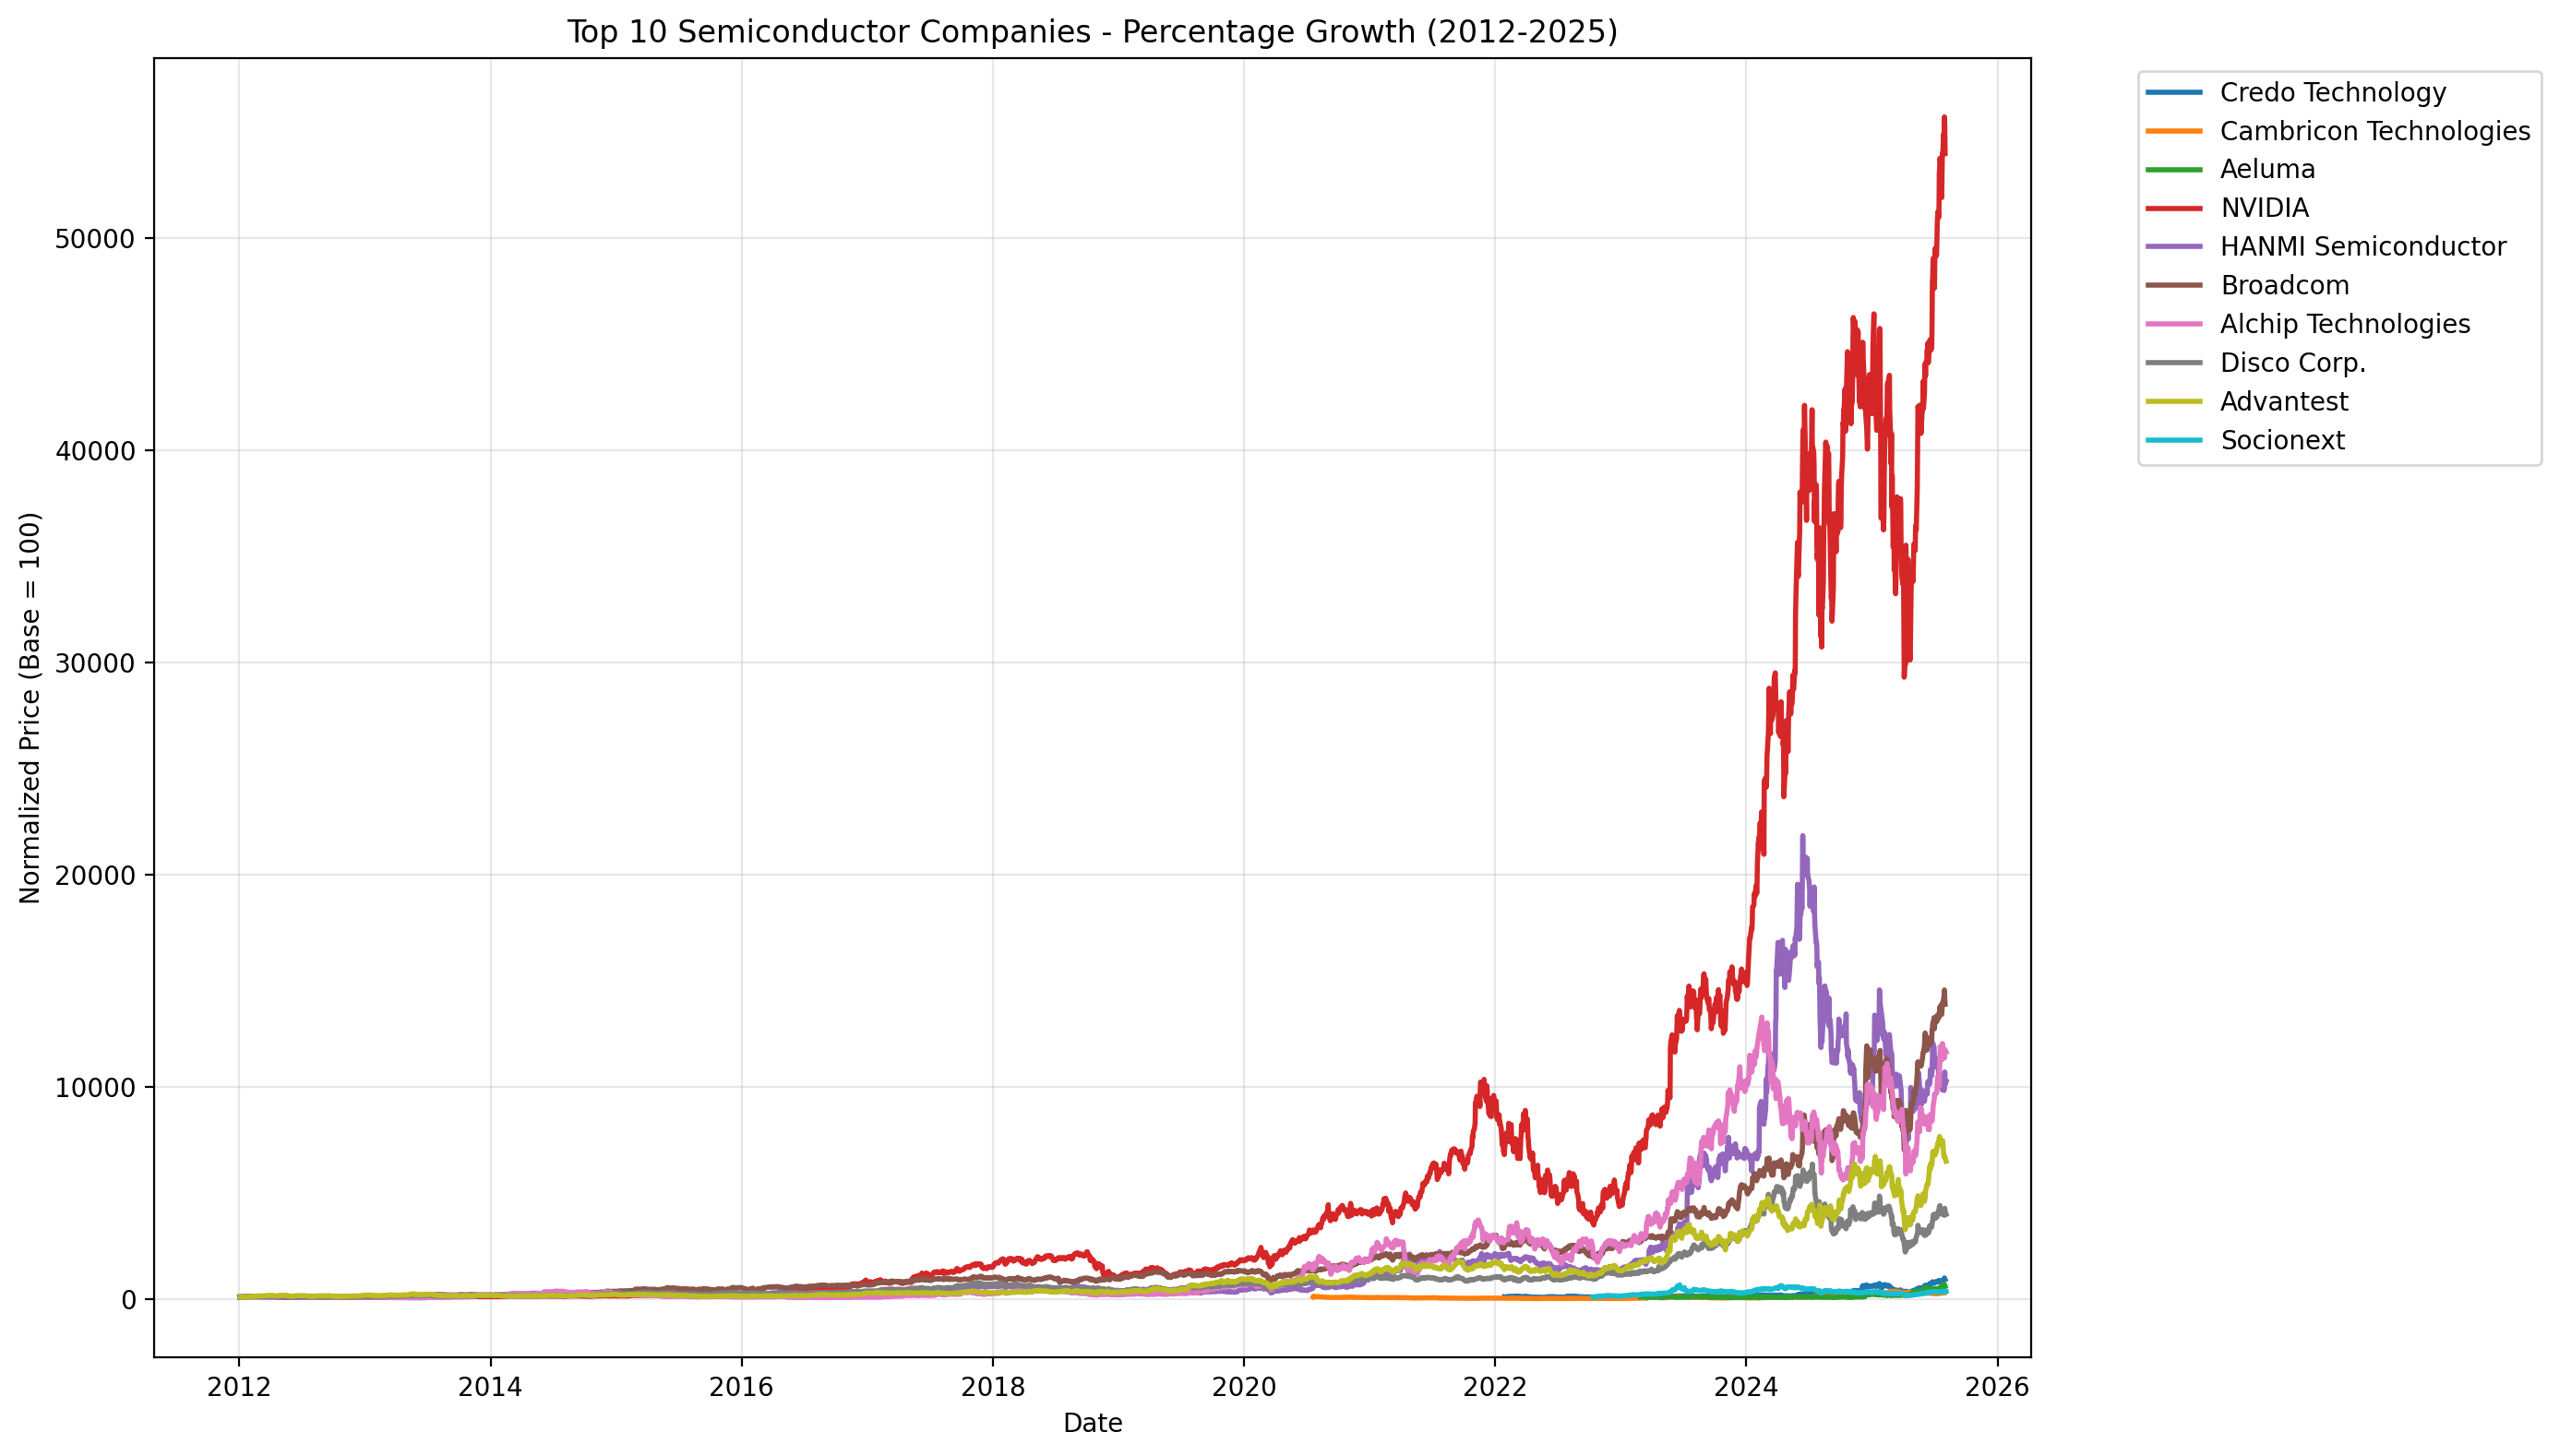

In [ ]:
# filter original data for only the top 10 companies
top_10_data = data[data['company_name'].isin(top_10_companies)]

# normalize prices to starting point for better comparison
def normalize_prices(group):
    first_price = group['close'].iloc[0]
    group['normalized_price'] = (group['close'] / first_price) * 100
    return group

top_10_normalized = top_10_data.groupby('company_name').apply(normalize_prices).reset_index(drop=True)

# Create time series plot
plt.figure(figsize=(14, 8))

for company in top_10_companies:
    company_data = top_10_normalized[top_10_normalized['company_name'] == company]
    plt.plot(company_data['date'], company_data['normalized_price'],
             label=company, linewidth=2)

plt.xlabel('Date')
plt.ylabel('Normalized Price (Base = 100)')
plt.title('Top 10 Semiconductor Companies - Percentage Growth (2012-2025)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# *Who benefited the MOST from the AI boom?*


**Percentage growth of TOP 10 Semiconductor Companies (during AI Boom)**
---
* Each line shows the **percentage growth**

* The highest line = best performer during the AI boom

* Normalized from 2023 year in dataset (start of AI Boom)

---

To evaluate stock performance over time:
1. We **grouped the dataset by company_name**, then **extracted the first and last closing price**
2. Then calculated the **total percentage return for each company**, and **normalized the prices**.


This step is crucial, because without normalization, companies with high share prices visually dominate the chart and distort the comparison. With normalization, the graph shows** relative growth rather than absolute prices** to compare long-term performance across all companies on the same scale.

Companies that **were not strong before but surged due to AI** will appear much stronger here.



<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Normalized Price (Base = 100 at Jan 2023)')

Text(0.5, 1.0, 'Top 10 Semiconductor Companies - Percentage Growth (2023-2025)')

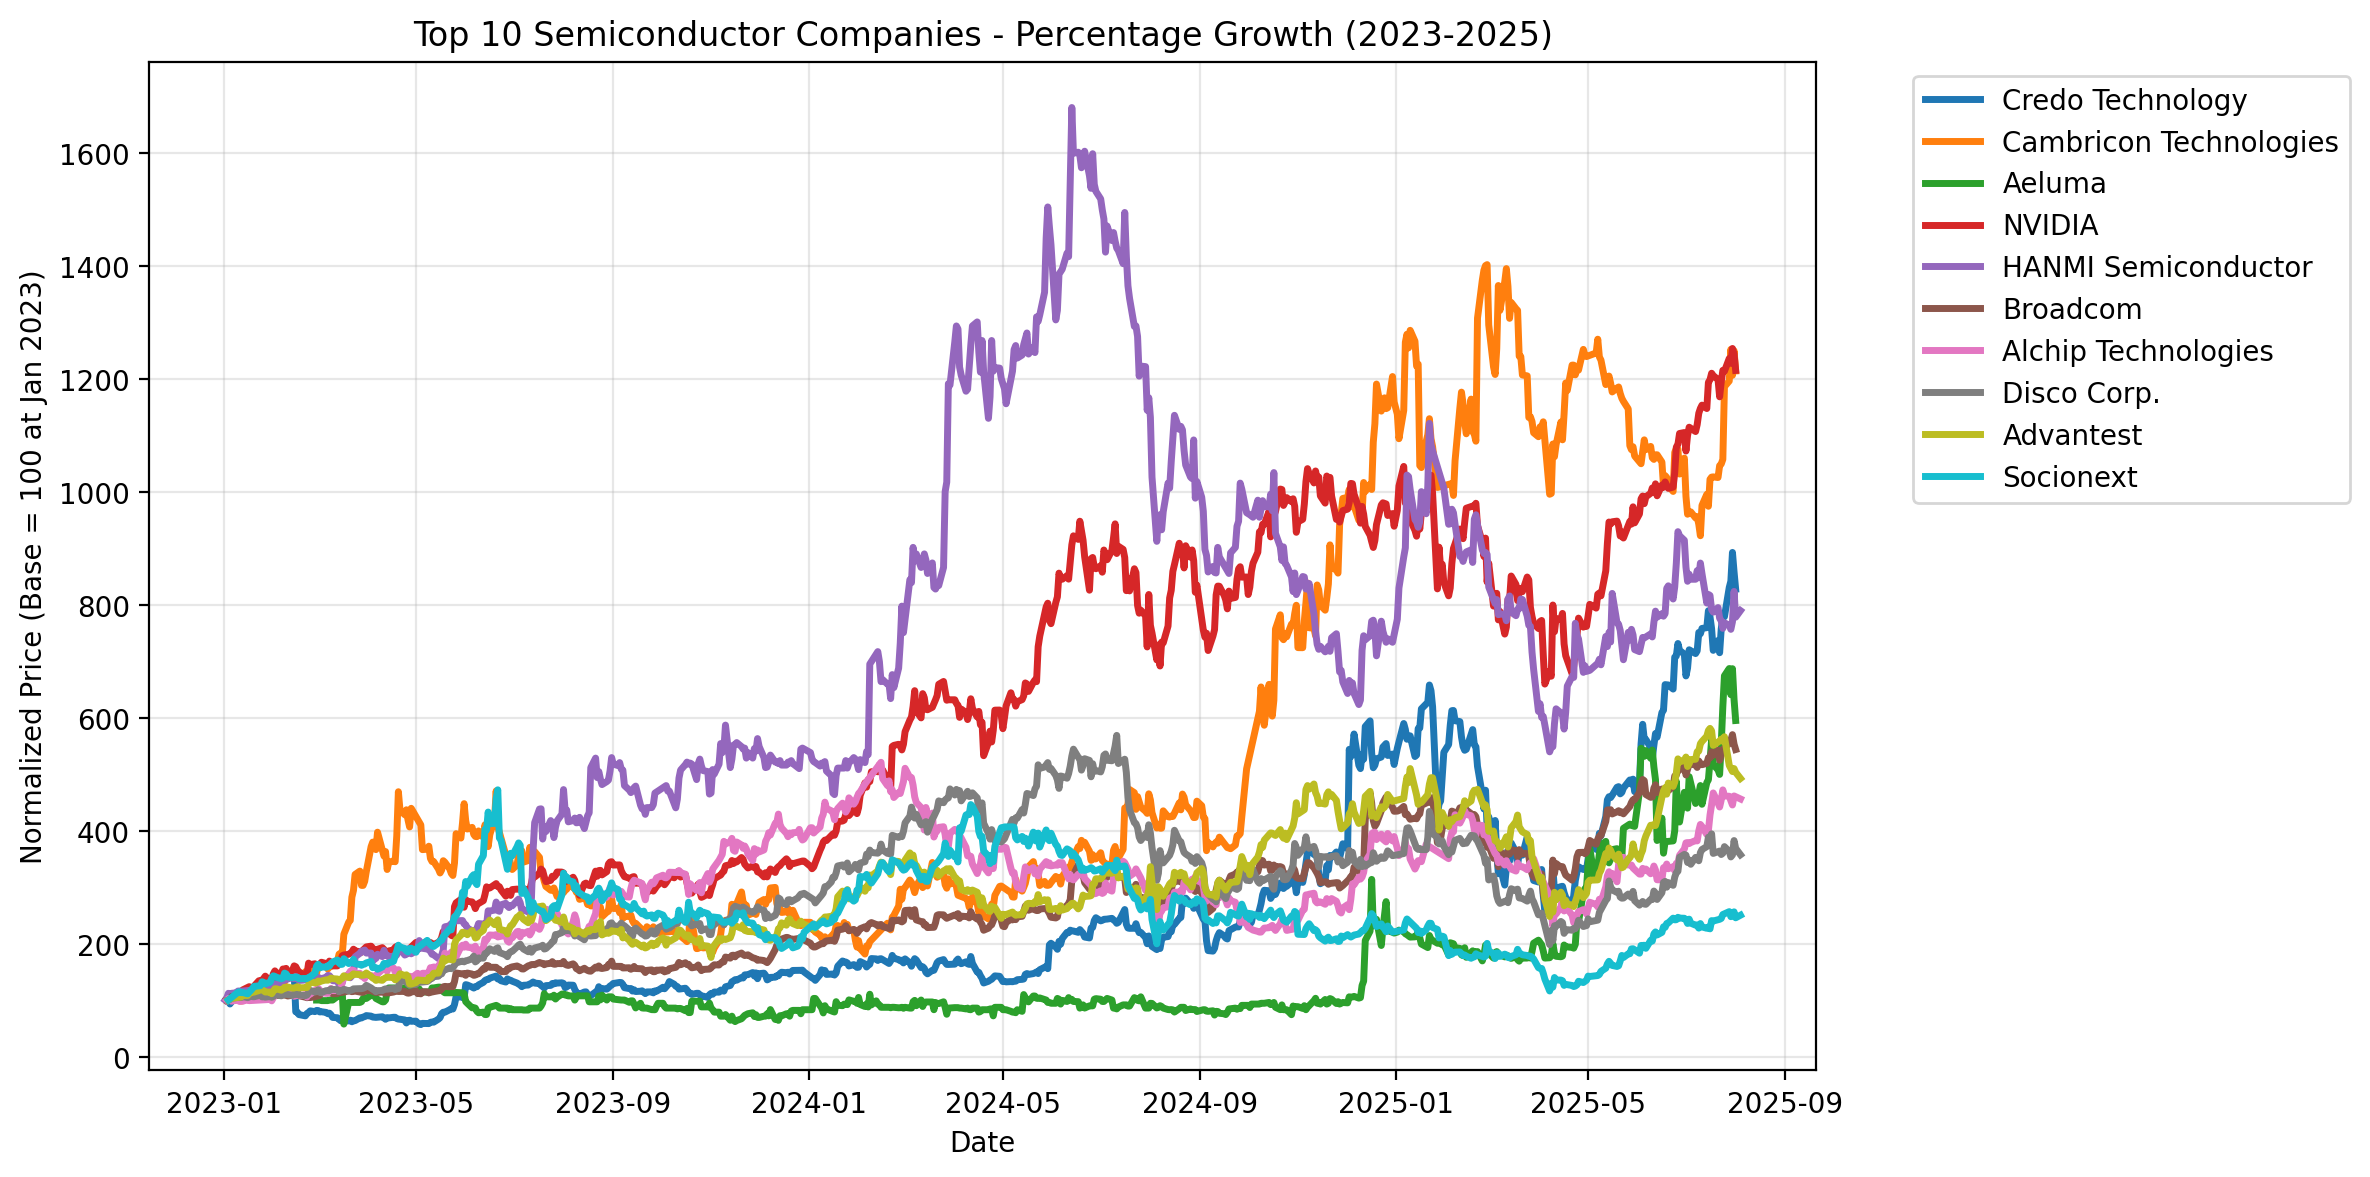

In [ ]:
# Focus specifically on the AI boom period
ai_boom_data = data[data['date'] >= '2023-01-01']
ai_boom_top_10 = ai_boom_data[ai_boom_data['company_name'].isin(top_10_companies)]

# Normalize for AI boom period specifically
ai_boom_normalized = ai_boom_top_10.groupby('company_name').apply(
    lambda x: x.assign(normalized_ai=(x['close'] / x['close'].iloc[0]) * 100)
).reset_index(drop=True)

# Create AI boom focused plot
plt.figure(figsize=(12, 6))

for company in top_10_companies:
    company_data = ai_boom_normalized[ai_boom_normalized['company_name'] == company]
    if not company_data.empty:
        plt.plot(company_data['date'], company_data['normalized_ai'],
                 label=company, linewidth=2.5)

plt.xlabel('Date')
plt.ylabel('Normalized Price (Base = 100 at Jan 2023)')
plt.title('Top 10 Semiconductor Companies - Percentage Growth (2023-2025)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate key metrics for the top 10 companies
def calculate_metrics(group):
    start_price = group['close'].iloc[0]
    end_price = group['close'].iloc[-1]
    total_return = (end_price / start_price - 1) * 100

    # Calculate volatility - risk
    daily_returns = group['close'].pct_change().dropna()
    volatility = daily_returns.std() * np.sqrt(252) * 100

    return pd.Series({
        'total_return_pct': total_return,
        'volatility_pct': volatility,
        'final_normalized_price': (end_price / start_price) * 100
    })

top_10_metrics = top_10_data.groupby('company_name').apply(calculate_metrics).reset_index()
print("\nDetailed Metrics for Top 10 Companies:")
print(top_10_metrics.sort_values('total_return_pct', ascending=False))


Detailed Metrics for Top 10 Companies:
             company_name  total_return_pct  volatility_pct  \
8                  NVIDIA      53876.319141       45.197617   
3                Broadcom      13791.522555       37.300642   
2     Alchip Technologies      11531.336378       59.389262   
7     HANMI Semiconductor      10159.233880       49.651984   
0               Advantest       6392.803045       44.550187   
6             Disco Corp.       3895.059966       39.975675   
5        Credo Technology        823.261812       79.517183   
1                  Aeluma        494.857134      125.639268   
9               Socionext        257.391083       63.354667   
4  Cambricon Technologies        224.435026       68.355792   

   final_normalized_price  
8            53976.319141  
3            13891.522555  
2            11631.336378  
7            10259.233880  
0             6492.803045  
6             3995.059966  
5              923.261812  
1              594.857134  
9             

**Equipment Companies Showing Strength**
Advantest (semiconductor testing equipment)  strong performer
Disco Corp (semiconductor processing equipment) - consistent growth
This suggests the entire semiconductor ecosystem is benefiting, not just chip designers


Clear winners emerged early and maintained leadership

The AI boom created a "rising tide" but amplified existing leaders rather than creating new ones

Quality companies with lower volatility (Broadcom, Disco) provided excellent risk-adjusted returns

Most companies show their steepest growth curves post-2020

The COVID period appears to be an inflection point for semiconductor demand

2023 AI boom created a second, even steeper acceleration for leaders

In [ ]:
data.head(10)

,index,company_name,stock_name,date,open,high,low,close,volume
0,0,NVIDIA,NVDA,2012-01-03,0.327805,0.330097,0.321157,0.321845,468044000
1,1,NVIDIA,NVDA,2012-01-04,0.322074,0.326888,0.319094,0.325513,347372000
2,2,NVIDIA,NVDA,2012-01-05,0.323908,0.338808,0.322533,0.337204,563548000
3,3,NVIDIA,NVDA,2012-01-06,0.336974,0.337204,0.329410,0.333307,533252000
4,4,NVIDIA,NVDA,2012-01-09,0.333536,0.339725,0.331014,0.333307,508244000
5,5,NVIDIA,NVDA,2012-01-10,0.338350,0.338579,0.329639,0.331931,546328000
6,6,NVIDIA,NVDA,2012-01-11,0.328951,0.331931,0.323908,0.325283,484272000
7,7,NVIDIA,NVDA,2012-01-12,0.325971,0.326200,0.316114,0.323220,652364000
8,8,NVIDIA,NVDA,2012-01-13,0.320928,0.321616,0.313134,0.314739,504300000
9,9,NVIDIA,NVDA,2012-01-17,0.319553,0.319553,0.309466,0.309925,627176000


# **Bar Charts**
Red bar is significantly higher relative to the blue bar = these are companies that saw a particular acceleration due to the AI trend, even if their overall long-term trajectory wasn't as steep as a historical giant like NVIDIA.

Taller blue bar but more moderate red bar indicate solid stability that aren't as directly or dramatically influenced by the current AI narrative


<Figure size 1200x600 with 0 Axes>

<BarContainer object of 10 artists>

Text(0, 0.5, 'Total Return (%)')

Text(0.5, 1.0, 'Total Returns (2012-End of Data) for Top 10 Semiconductor Companies')

([<matplotlib.axis.XTick at 0x796e035a21e0>,
 [Text(0, 0, 'Credo Technology'),
  Text(1, 0, 'Cambricon Technologies'),
  Text(2, 0, 'Aeluma'),
  Text(3, 0, 'NVIDIA'),
  Text(4, 0, 'HANMI Semiconductor'),
  Text(5, 0, 'Broadcom'),
  Text(6, 0, 'Alchip Technologies'),
  Text(7, 0, 'Disco Corp.'),
  Text(8, 0, 'Advantest'),
  Text(9, 0, 'Socionext')])

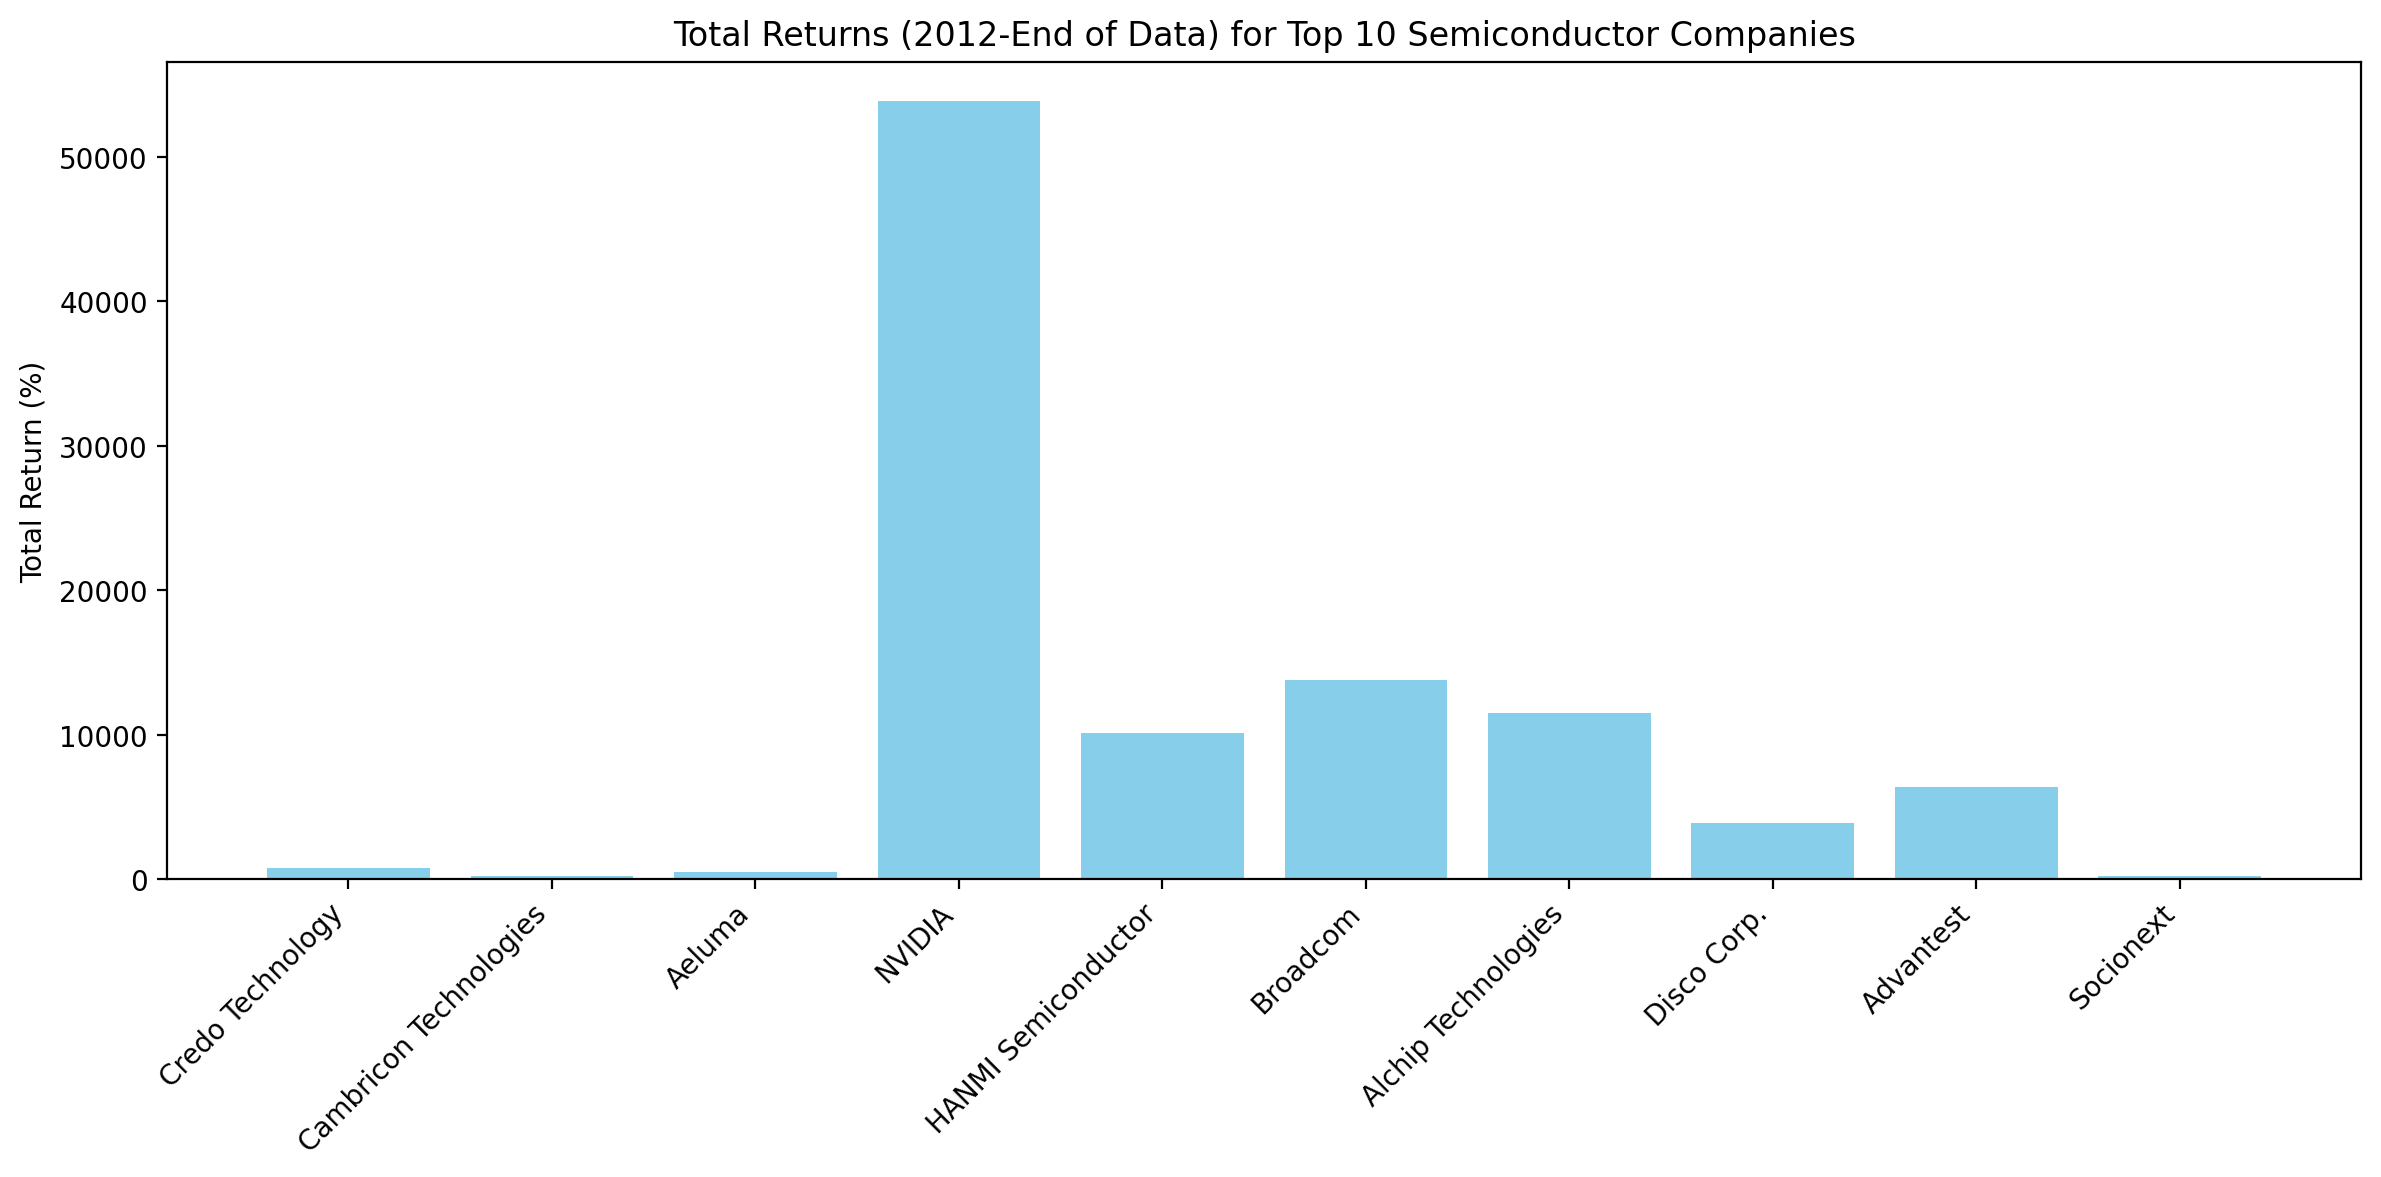

<Figure size 1200x600 with 0 Axes>

<BarContainer object of 10 artists>

Text(0, 0.5, 'Total Return (%)')

Text(0.5, 1.0, 'Total Returns (2023-End of Data, AI Boom) for Top 10 Semiconductor Companies')

([<matplotlib.axis.XTick at 0x796e037508c0>,
 [Text(0, 0, 'Credo Technology'),
  Text(1, 0, 'Cambricon Technologies'),
  Text(2, 0, 'Aeluma'),
  Text(3, 0, 'NVIDIA'),
  Text(4, 0, 'HANMI Semiconductor'),
  Text(5, 0, 'Broadcom'),
  Text(6, 0, 'Alchip Technologies'),
  Text(7, 0, 'Disco Corp.'),
  Text(8, 0, 'Advantest'),
  Text(9, 0, 'Socionext')])

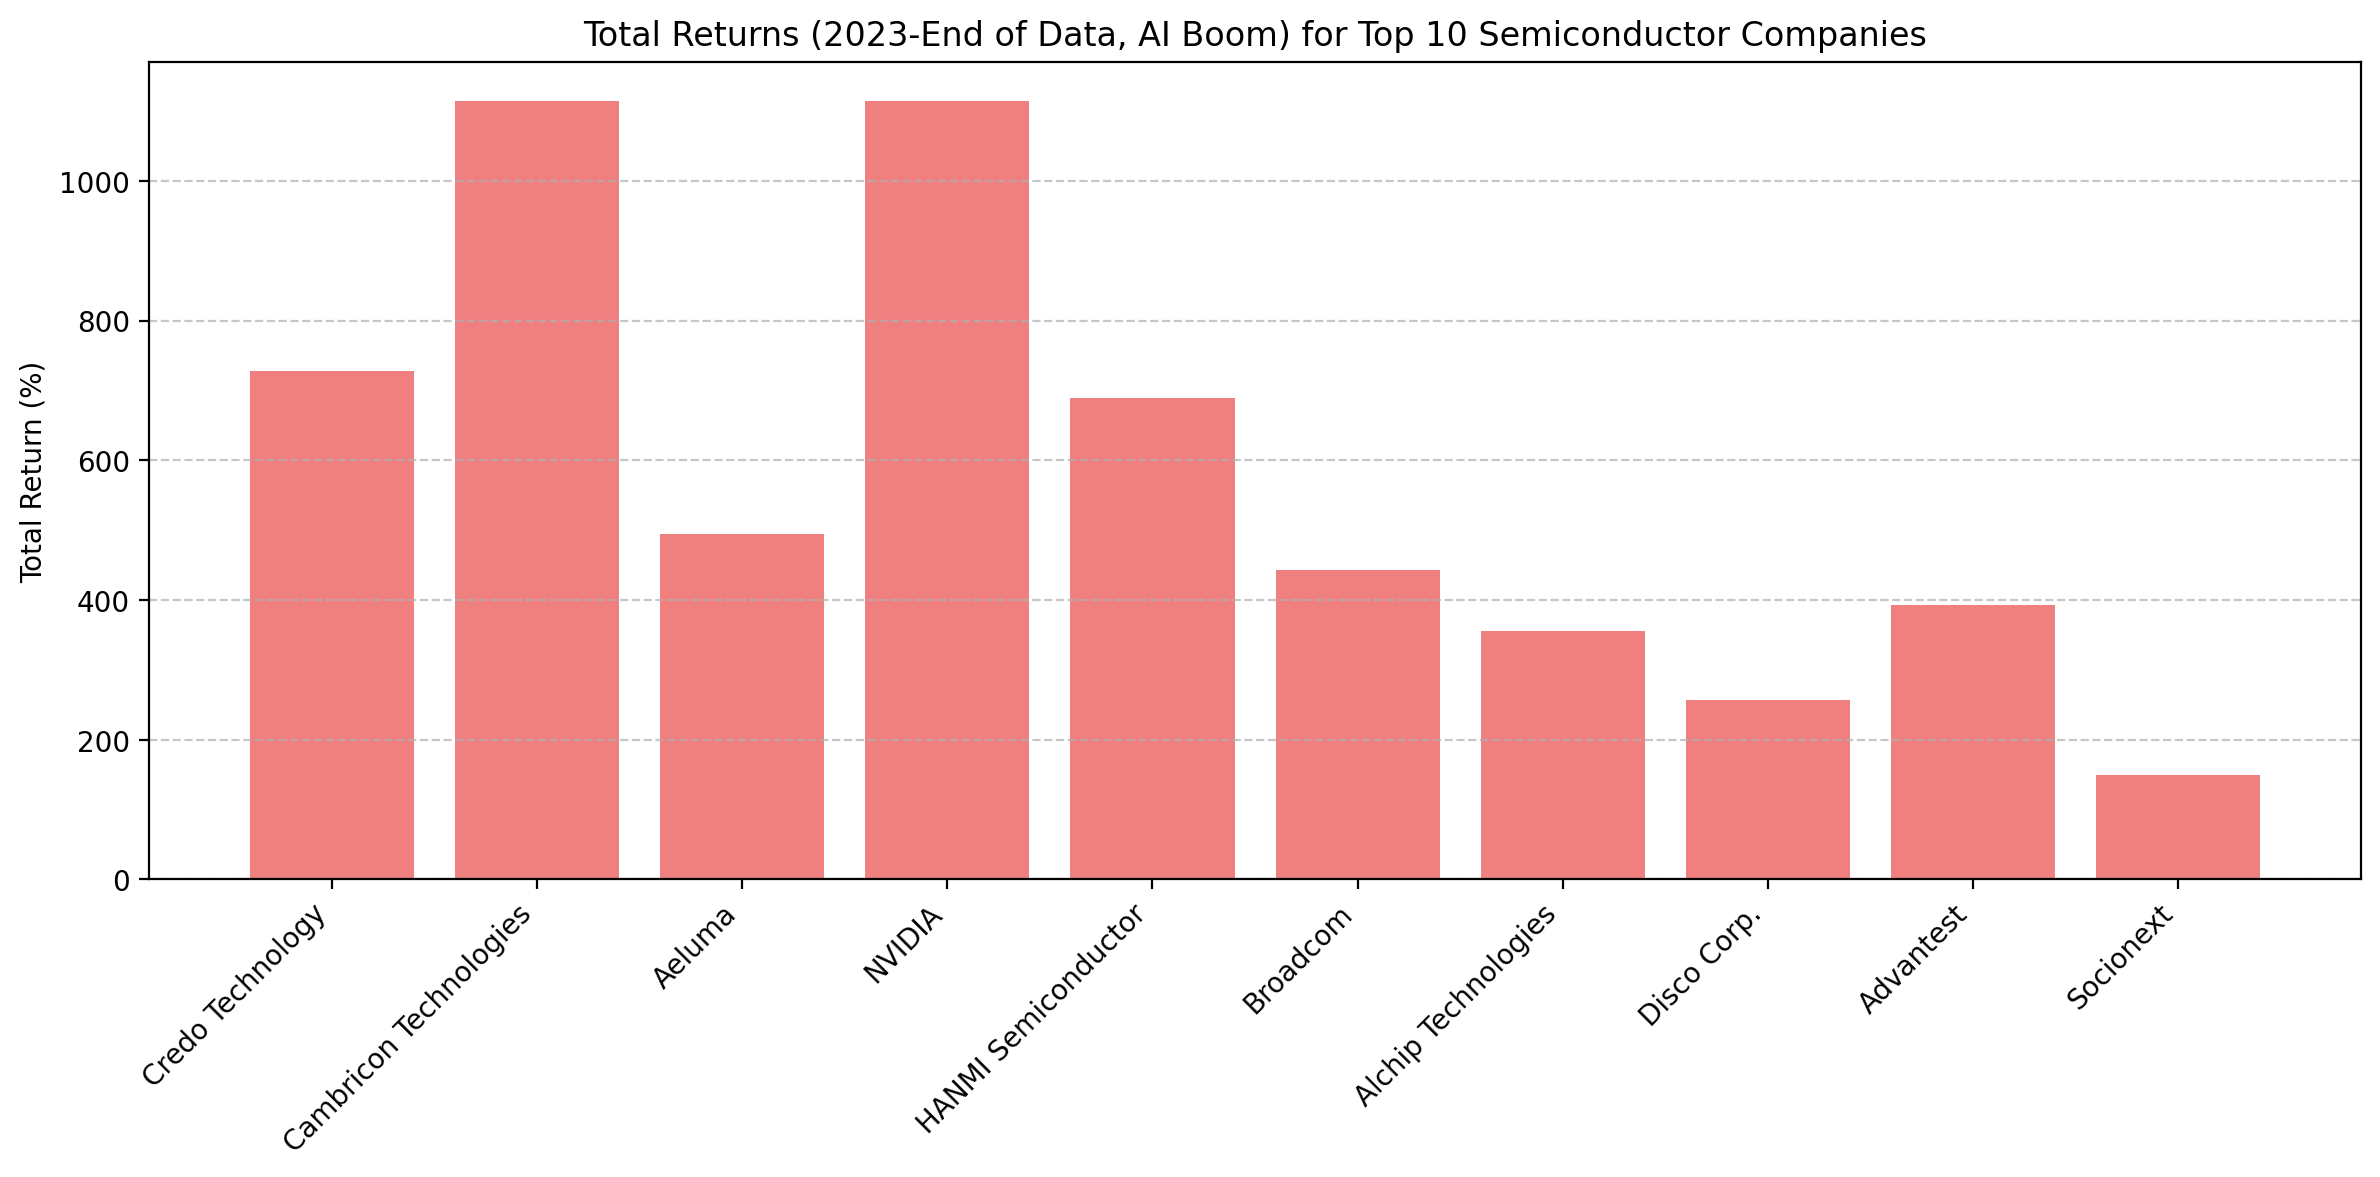

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate Long-Term Returns for Top 10 Companies
# Filter the original full data for only the top 10 companies
top_10_full_data = data[data['company_name'].isin(top_10_companies)]

# Group by company and stock to calculate first and last close prices
first_close_full = top_10_full_data.groupby(['company_name', 'stock_name'])['close'].first()
last_close_full = top_10_full_data.groupby(['company_name', 'stock_name'])['close'].last()

# Calculate total return percentage for the full period
long_term_total_return_pct = ((last_close_full / first_close_full) - 1) * 100

# Convert to DataFrame and get mean return per company
long_term_df = long_term_total_return_pct.reset_index(name='total_return_pct_long_term')
long_term_returns = long_term_df.groupby('company_name')['total_return_pct_long_term'].mean()

# Calculate AI Boom Returns (2023-2025) for Top 10 Companies
# ai_boom_normalized  has prices normalized to 100 at Jan 2023
# So, the return is simply the last normalized price minus 100
ai_boom_last_values = ai_boom_normalized.groupby('company_name')['normalized_ai'].last()
ai_boom_returns = ai_boom_last_values - 100

# Combine into one DataFrame for plotting
combined_returns = pd.DataFrame({
    'Long-Term Return (%)': long_term_returns,
    'AI Boom Return (%)': ai_boom_returns
}).reindex(top_10_companies)  # Reindex to maintain consistent company order

x = np.arange(len(top_10_companies))

# lot Long-Term Returns Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(x, combined_returns['Long-Term Return (%)'], color='skyblue')
plt.ylabel('Total Return (%)')
plt.title('Total Returns (2012-End of Data) for Top 10 Semiconductor Companies')
plt.xticks(x, top_10_companies, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot AI Boom Returns Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(x, combined_returns['AI Boom Return (%)'], color='lightcoral')
plt.ylabel('Total Return (%)')
plt.title('Total Returns (2023-End of Data, AI Boom) for Top 10 Semiconductor Companies')
plt.xticks(x, top_10_companies, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Bar Chart Readings:**

* **Overall Dominance**: Companies with high bars in both charts are those that have demonstrated strong performance historically and have also capitalized significantly on the recent AI surge.

  * NVIDIA 53,876% long-term return, 1,114%  AI Boom period

* **AI Boom Beneficiaries:** Companies that saw a particular acceleration due to the AI trend, even if their overall long-term trajectory wasn't as steep as a historical giant.

  * Cambricon long-term return of 224% highest return 1,113%


* **Solid Performers**: Companies with good long-term returns (blue bar) but more moderate AI boom returns (red bar) might indicate solid performance that aren't as directly or dramatically influenced by the current AI narrative but still perform well.


  * Broadcom 13,791% long-term, 443% AI Boom

  * Alchip 11,531% long-term, 355% AI Boom

  * HANMI 10,159% long-term, 689% AI Boom

* **Consistent Growth**: Similar returns for both periods

  * Credo Technology 823% long-term growth ,727%  AI boom
  
  This remarkable consistency from a pure infrastructure provider underscores our main point:
**Once market speculation cools off, the companies that actually Support the foundation of AI systems continue to deliver steady, reliable growth**

# **Risk/Return Analysis**

In [ ]:
# Calculate daily returns
data['daily_return'] = data.groupby('company_name')['close'].pct_change()

# Calculate annualized volatility for each company
# We filter for companies in top_10_companies to ensure we only calculate for relevant ones.
annualized_volatility = data[data['company_name'].isin(top_10_companies)].groupby('company_name')['daily_return'].std() * np.sqrt(252)

# Prepare data for annualized return calculation
# Get the first and last date for each company to determine the period length
company_first_date = data.groupby('company_name')['date'].min()
company_last_date = data.groupby('company_name')['date'].max()

# Calculate the number of years for each company's data
company_years = ((company_last_date - company_first_date).dt.days / 365.25)

# Convert long_term_returns (total_return_pct_long_term) from percentage to decimal
long_term_returns_decimal = long_term_returns / 100

# Merge total returns and number of years
return_period_data = pd.DataFrame({
    'total_return_decimal': long_term_returns_decimal,
    'num_years': company_years
}).loc[top_10_companies] # Filter for top 10 companies and reindex

# Calculate annualized return
# Avoid division by zero or negative years if any data issues occur, though unlikely here.
annualized_return = (1 + return_period_data['total_return_decimal'])**(1 / return_period_data['num_years']) - 1

# Convert annualized return to percentage for plotting
annualized_return_pct = annualized_return * 100

# Combine volatility and annualized return into a single DataFrame
risk_return_df = pd.DataFrame({
    'Annualized Volatility': annualized_volatility,
    'Annualized Return': annualized_return_pct
}).loc[top_10_companies] # Ensure order and only top 10 companies

display(risk_return_df.head(10))


,Annualized Volatility,Annualized Return
company_name,,
Credo Technology,0.795172,88.376720
Cambricon Technologies,0.683558,26.349066
Aeluma,1.256393,108.741740
NVIDIA,0.451976,58.941606
HANMI Semiconductor,0.496520,40.607083
Broadcom,0.373006,43.820905
Alchip Technologies,0.593893,44.878981
Disco Corp.,0.399757,31.193097
Advantest,0.445502,35.968717


<Figure size 1200x800 with 0 Axes>

<Axes: xlabel='Annualized Volatility', ylabel='Annualized Return'>

Text(0.8151718311185746, 88.87671996862075, 'Credo Technology')

Text(0.7035579239528779, 26.84906649656954, 'Cambricon Technologies')

Text(1.2763926799985712, 109.24173972068574, 'Aeluma')

...

Text(0.465501865824817, 36.468716671059966, 'Advantest')

Text(0.6535466682101385, 57.79835749827119, 'Socionext')

Text(0.5, 1.0, 'Risk-Return Analysis: Annualized Volatility vs. Annualized Return (Top 10 Companies)')

Text(0.5, 0, 'Annualized Volatility (%)')

Text(0, 0.5, 'Annualized Return (%)')

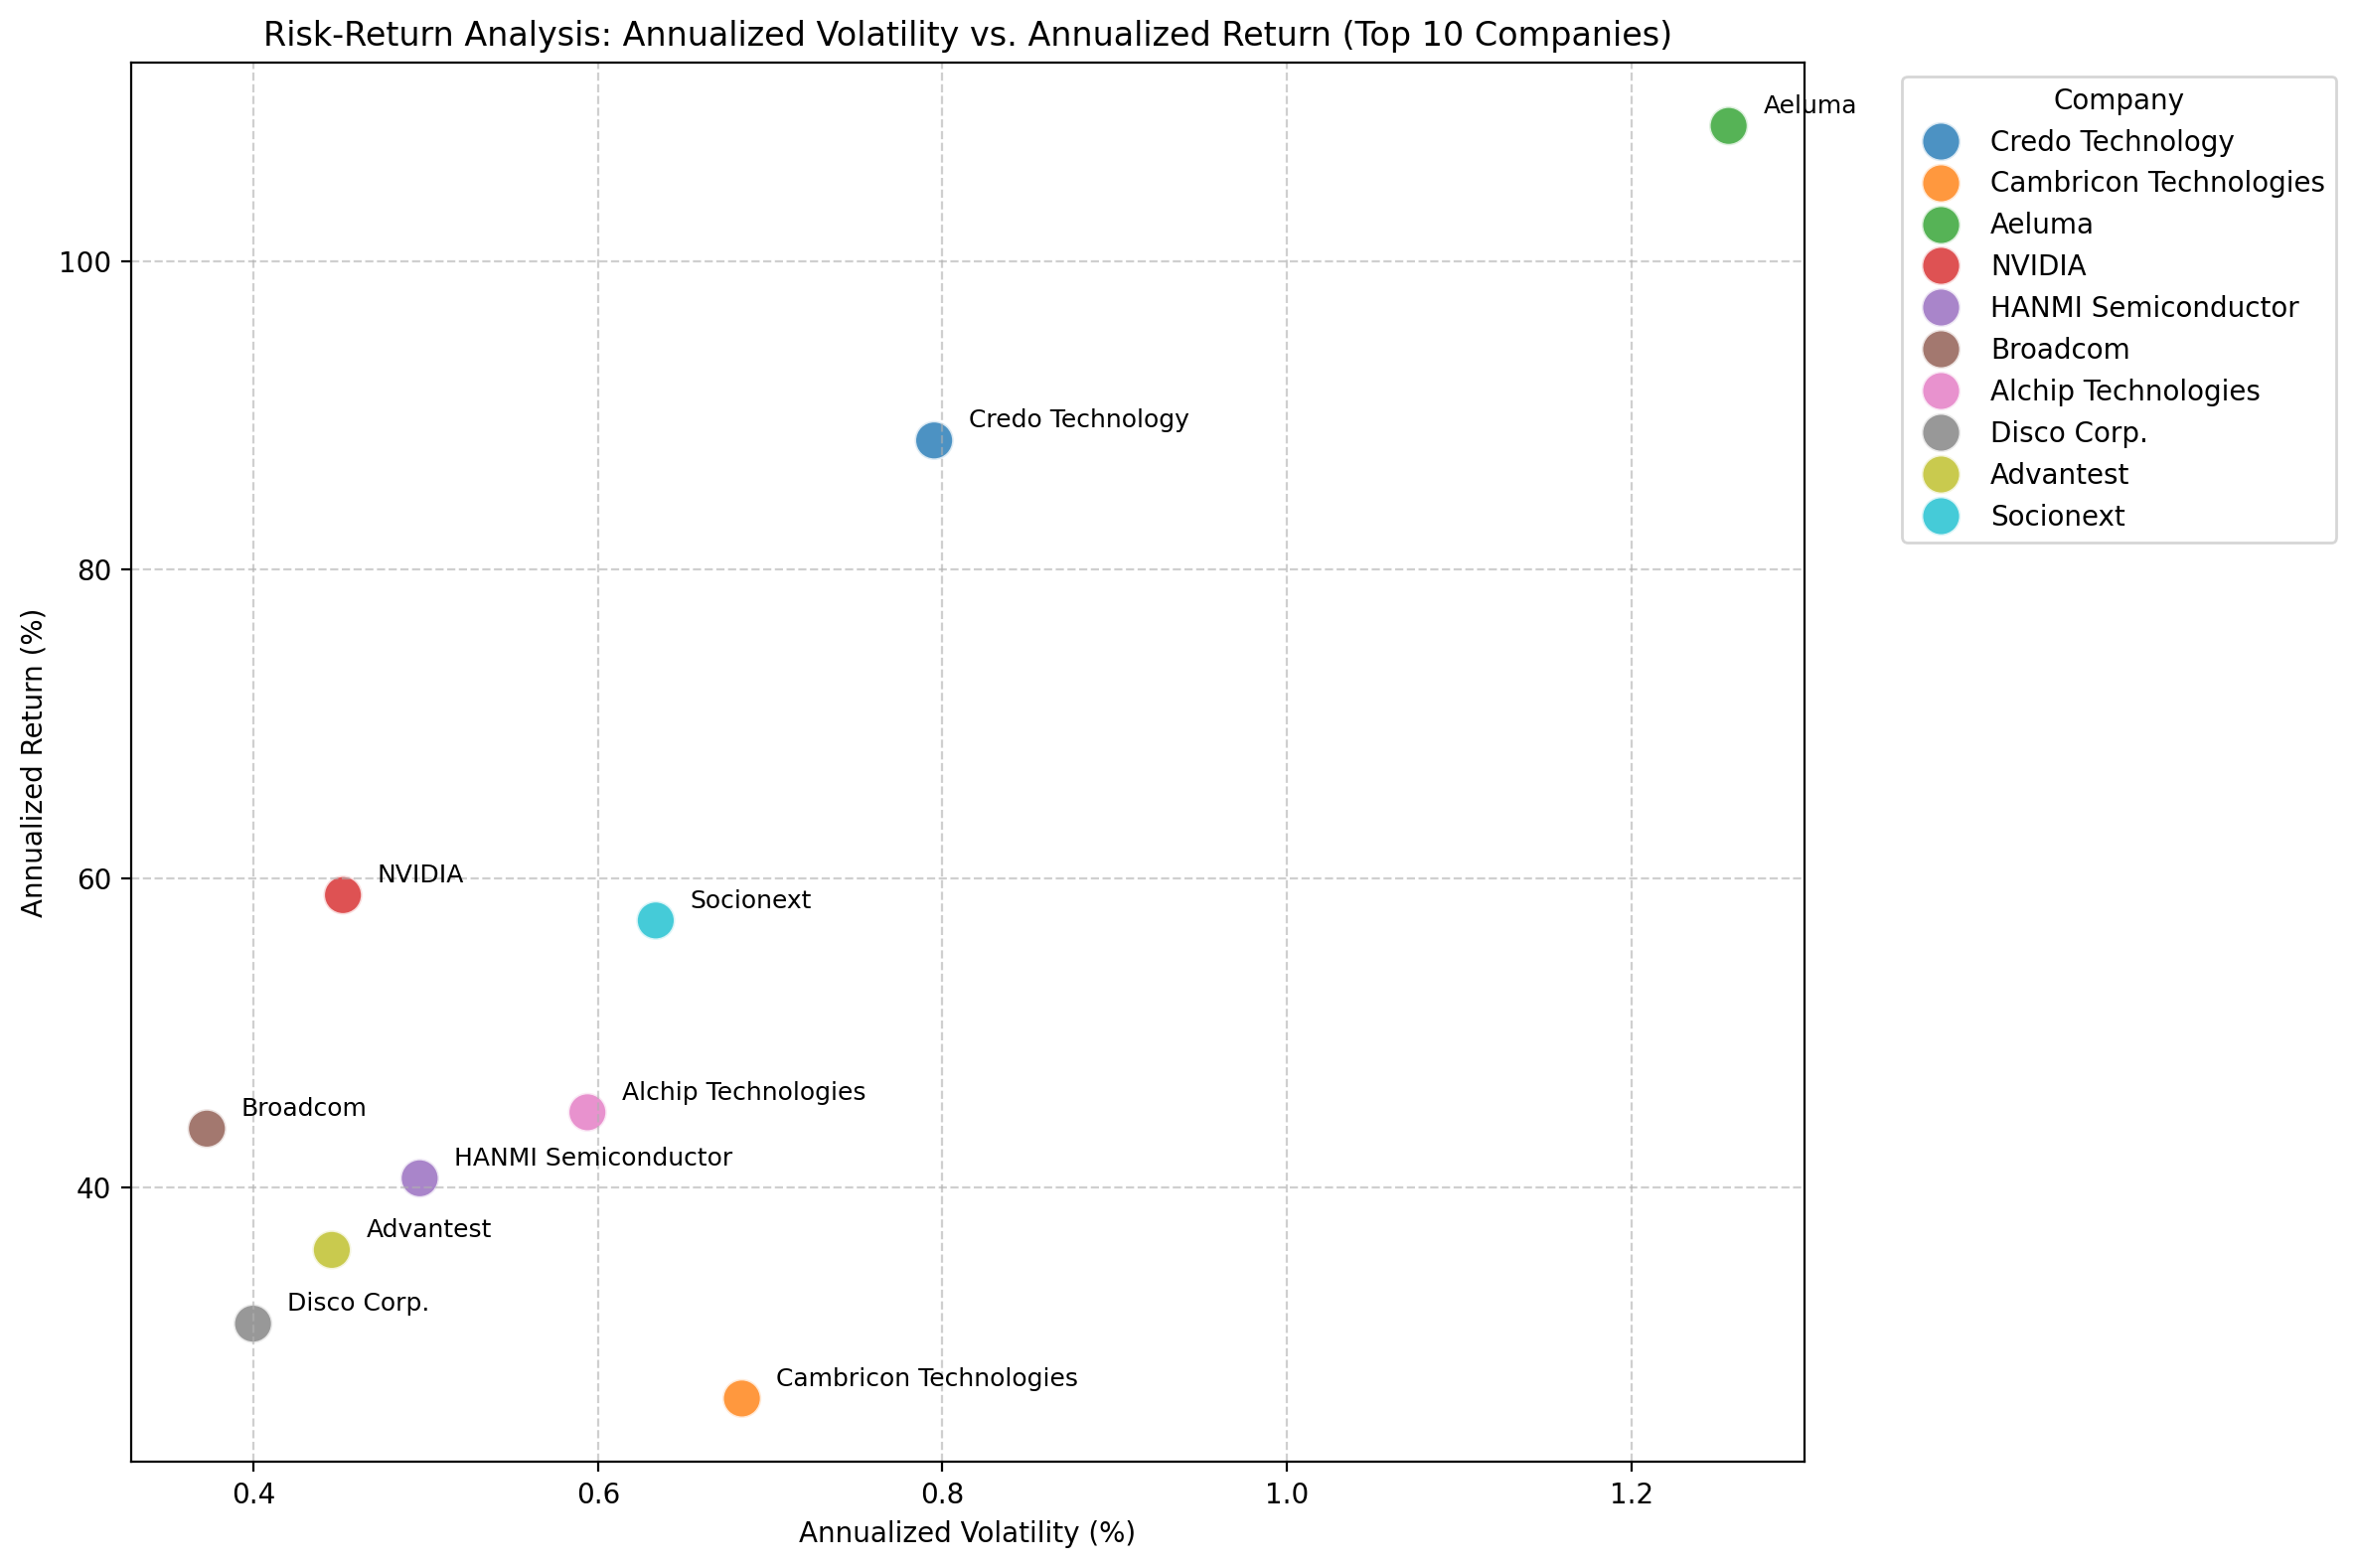

In [ ]:
plt.figure(figsize=(12, 8))

# Create the scatter plot
sns.scatterplot(
    x='Annualized Volatility',
    y='Annualized Return',
    data=risk_return_df,
    hue=risk_return_df.index, # Color points by company name
    s=200, # Size of the points
    alpha=0.8
)

# Add annotations for each company with a slight offset
for i, row in risk_return_df.iterrows():
    plt.text(row['Annualized Volatility'] + 0.02, row['Annualized Return'] + 0.5, i, fontsize=9, ha='left', va='bottom')

plt.title('Risk-Return Analysis: Annualized Volatility vs. Annualized Return (Top 10 Companies)')
plt.xlabel('Annualized Volatility (%)')
plt.ylabel('Annualized Return (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Company')
plt.tight_layout()
plt.show()

# **Risk/Return Analysis Conclusions**
From  risk–return plot, we can see a clear pattern that supports the idea that infrastructure outperforms speculation

**Aeluma , Credo Technology** delivers exceptionally high returns with moderate volatility efficient, sustainable growth, they are infrastructure-focused, They deliver strong long-term returns without the extreme risk we expect from speculative leaders

**NVIDIA**is not the most efficient performer here


Companies that build the underlying infrastructure like **Credo Technology, Broadcom, HANMI Semiconductor, Disco Corp., and Advantest**—show lower risk with  consistent returns.

In [ ]:
credo_data = data[(data['company_name'] == 'CREDO') | (data['stock_name'] == 'CRDO')]

display(credo_data.head())

,index,company_name,stock_name,date,open,high,low,close,volume,daily_return
111634,111634,Credo Technology,CRDO,2022-01-27,12.10,12.500,10.80,11.65,5371700,NaN
111635,111635,Credo Technology,CRDO,2022-01-28,11.64,12.325,11.05,11.19,1317000,-0.039485
111636,111636,Credo Technology,CRDO,2022-01-31,11.44,12.490,11.20,12.12,838400,0.083110
111637,111637,Credo Technology,CRDO,2022-02-01,12.12,13.700,11.82,12.80,833000,0.056106
111638,111638,Credo Technology,CRDO,2022-02-02,13.09,13.415,12.80,13.40,2621600,0.046875


# **K-Means Clustering**



We use k-means clustering to see **how market days during AI boom are grouped** to see patterns are not obvious just by looking at the raw data, but clustering makes them easy to see and understand


Model shows **structure in financial data**, proving that **tmachine learning can help us better understand the stock market**

---
Each point is a trading day, and the two features used are:

**Close price** (scaled and log-transformed) on the x-axis

**Volume** (scaled and log-transformed) on the y-axis

**Red X marks the center** of each cluster — the average behavior of that group



In [ ]:
data.head(10)

,index,company_name,stock_name,date,open,high,low,close,volume,daily_return
0,0,NVIDIA,NVDA,2012-01-03,0.327805,0.330097,0.321157,0.321845,468044000,NaN
1,1,NVIDIA,NVDA,2012-01-04,0.322074,0.326888,0.319094,0.325513,347372000,0.011396
2,2,NVIDIA,NVDA,2012-01-05,0.323908,0.338808,0.322533,0.337204,563548000,0.035915
3,3,NVIDIA,NVDA,2012-01-06,0.336974,0.337204,0.329410,0.333307,533252000,-0.011557
4,4,NVIDIA,NVDA,2012-01-09,0.333536,0.339725,0.331014,0.333307,508244000,0.000000
5,5,NVIDIA,NVDA,2012-01-10,0.338350,0.338579,0.329639,0.331931,546328000,-0.004126
6,6,NVIDIA,NVDA,2012-01-11,0.328951,0.331931,0.323908,0.325283,484272000,-0.020028
7,7,NVIDIA,NVDA,2012-01-12,0.325971,0.326200,0.316114,0.323220,652364000,-0.006342
8,8,NVIDIA,NVDA,2012-01-13,0.320928,0.321616,0.313134,0.314739,504300000,-0.026241
9,9,NVIDIA,NVDA,2012-01-17,0.319553,0.319553,0.309466,0.309925,627176000,-0.015295


In [ ]:
# Filter rows where year is between 2023 and 2025
data_2023_2025 = data[data['date'].between('2023-01-01', '2025-12-31')]

In [ ]:
data_2023_2025.head()
data_2023_2025.tail()
print("Total rows:", len(data_2023_2025))


,index,company_name,stock_name,date,open,high,low,close,volume,daily_return
2768,2768,NVIDIA,NVDA,2023-01-03,14.837809,14.982681,14.083480,14.302285,401277000,-0.020460
2769,2769,NVIDIA,NVDA,2023-01-04,14.554063,14.839809,14.228353,14.735901,431324000,0.030318
2770,2770,NVIDIA,NVDA,2023-01-05,14.478132,14.551067,14.135436,14.252333,389168000,-0.032816
2771,2771,NVIDIA,NVDA,2023-01-06,14.461146,14.996670,14.021537,14.845804,405044000,0.041640
2772,2772,NVIDIA,NVDA,2023-01-09,15.270426,16.041740,15.127553,15.614120,504231000,0.051753


,index,company_name,stock_name,date,open,high,low,close,volume,daily_return
422724,422724,Kalray,ALKAL.PA,2025-07-28,0.660,0.686,0.644,0.661,84650,0.001515
422725,422725,Kalray,ALKAL.PA,2025-07-29,0.670,0.695,0.670,0.690,96811,0.043873
422726,422726,Kalray,ALKAL.PA,2025-07-30,0.695,0.760,0.671,0.700,175991,0.014493
422727,422727,Kalray,ALKAL.PA,2025-07-31,0.700,0.730,0.679,0.688,77266,-0.017143
422728,422728,Kalray,ALKAL.PA,2025-08-01,0.684,0.684,0.620,0.620,91221,-0.098837


Total rows: 96711


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
data_2023_2025 = data[data['date'].between('2023-01-01', '2025-12-31')]
# Drop columns
data_2023_2025 = data_2023_2025.drop(columns=['company_name', 'stock_name', 'date', 'open', 'high', 'low', 'daily_return'])

In [ ]:
data_2023_2025.head()

,index,close,volume
2768,2768,14.302285,401277000
2769,2769,14.735901,431324000
2770,2770,14.252333,389168000
2771,2771,14.845804,405044000
2772,2772,15.614120,504231000


In [ ]:
newDF = data_2023_2025.values  # numeric features

In [ ]:
for k in [3, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(newDF)

    # SSE (inertia)
    sse = kmeans.inertia_
    print(f"k = {k}, SSE (inertia): {sse}")

    # Silhouette on a random sample (e.g., 2000 points)
    sil = silhouette_score(newDF, labels, sample_size=2000, random_state=42)
    print(f"k = {k}, Silhouette score (sampled): {sil}\n")


k = 3, SSE (inertia): 2.034366553398242e+19
k = 3, Silhouette score (sampled): 0.9355317281949155

k = 6, SSE (inertia): 6.640268763761802e+18
k = 6, Silhouette score (sampled): 0.8025864293018465



In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Take only necessary numeric columns
X = data_2023_2025[['close', 'volume']].copy()

# Log transform to reduce extreme skew
X['close'] = np.log1p(X['close'])
X['volume'] = np.log1p(X['volume'])

# Standard scaling for fair clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("After scaling:")
print(X_scaled[:5])

After scaling:
[[-0.7658208   2.28504426]
 [-0.75316083  2.31233514]
 [-0.76730221  2.27346356]
 [-0.75000747  2.28857573]
 [-0.7285554   2.37136149]]


In [ ]:
for k in [3, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    data_2023_2025[f'cluster_{k}'] = kmeans.labels_
    print(data_2023_2025.groupby(f'cluster_{k}')[['close', 'volume']].mean())

                  close        volume
cluster_3                            
0             85.419717  1.310180e+07
1             29.081674  1.545384e+05
2          16505.623167  4.606533e+06
                  close        volume
cluster_6                            
0             75.101704  2.433872e+07
1             17.516115  2.010139e+05
2           1381.022603  3.952608e+06
3             32.470158  2.396045e+02
4             74.295429  9.084317e+05
5          50839.462699  5.809425e+06


In [ ]:
import matplotlib.pyplot as plt

def plot_clusters(X_scaled, labels, centers, k):
    plt.figure(figsize=(8,6))

    # Scatter points colored by cluster
    plt.scatter(
        X_scaled[:,0],
        X_scaled[:,1],
        c=labels,
        cmap='viridis',
        s=10,
        alpha=0.6
    )

    # Plot cluster centers
    plt.scatter(
        centers[:,0],
        centers[:,1],
        c='red',
        s=200,
        marker='X',
        edgecolors='black',
        linewidth=1.5,
        label='Cluster Centers'
    )

    plt.title(f"K-Means Clusters (k={k})")
    plt.xlabel("Close (scaled+log)")
    plt.ylabel("Volume (scaled+log)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


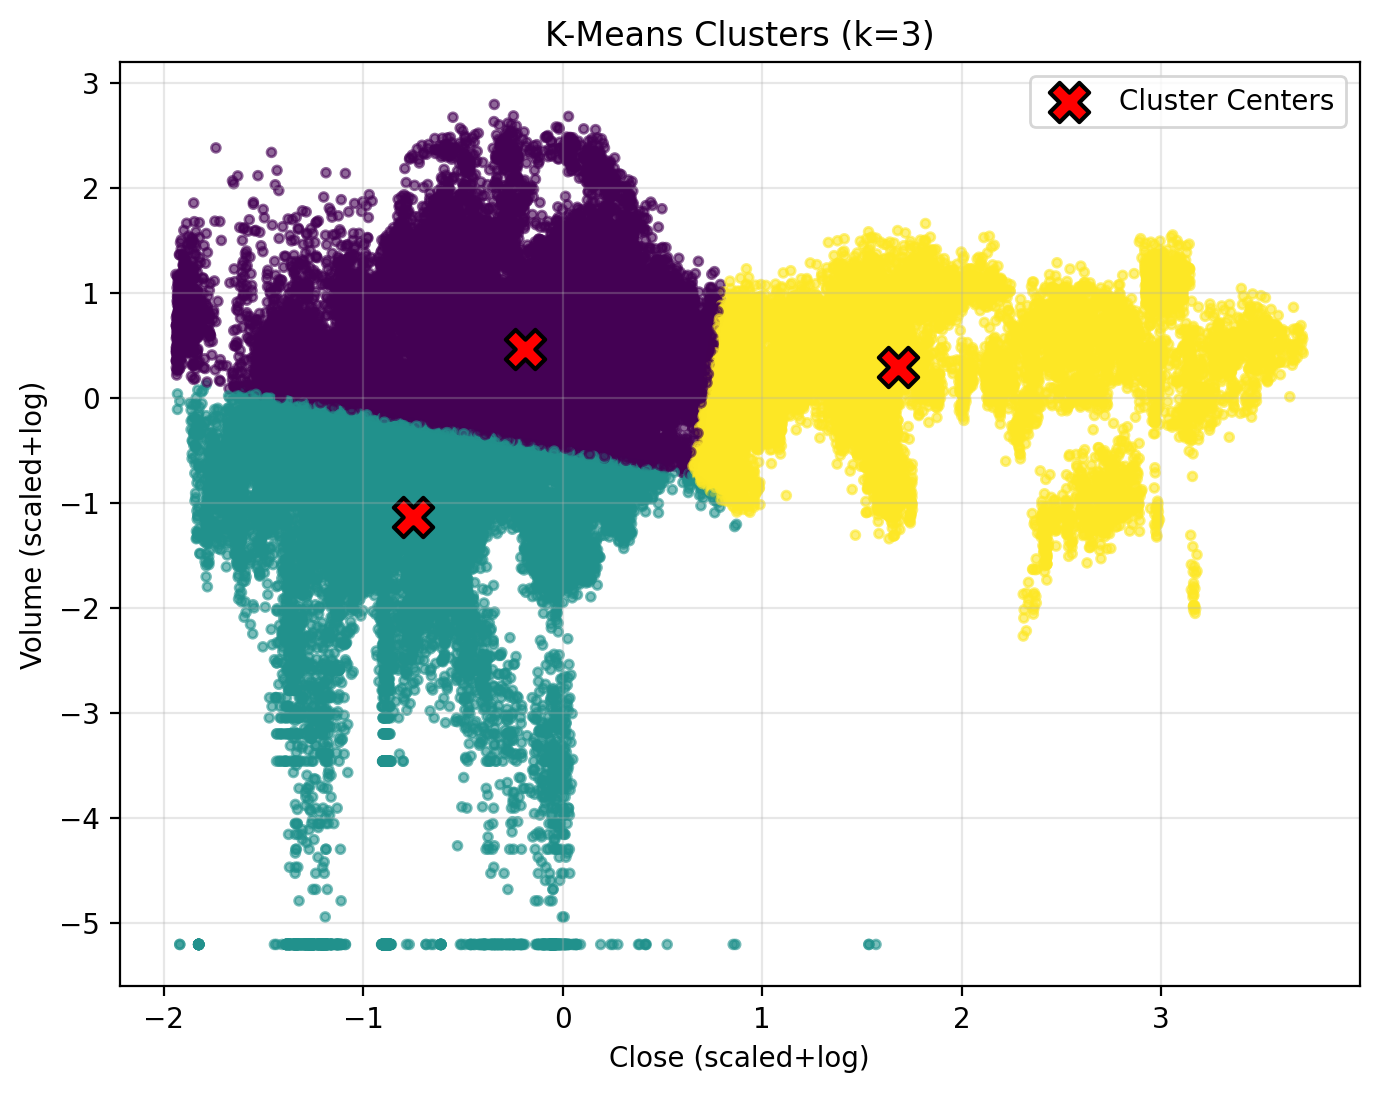

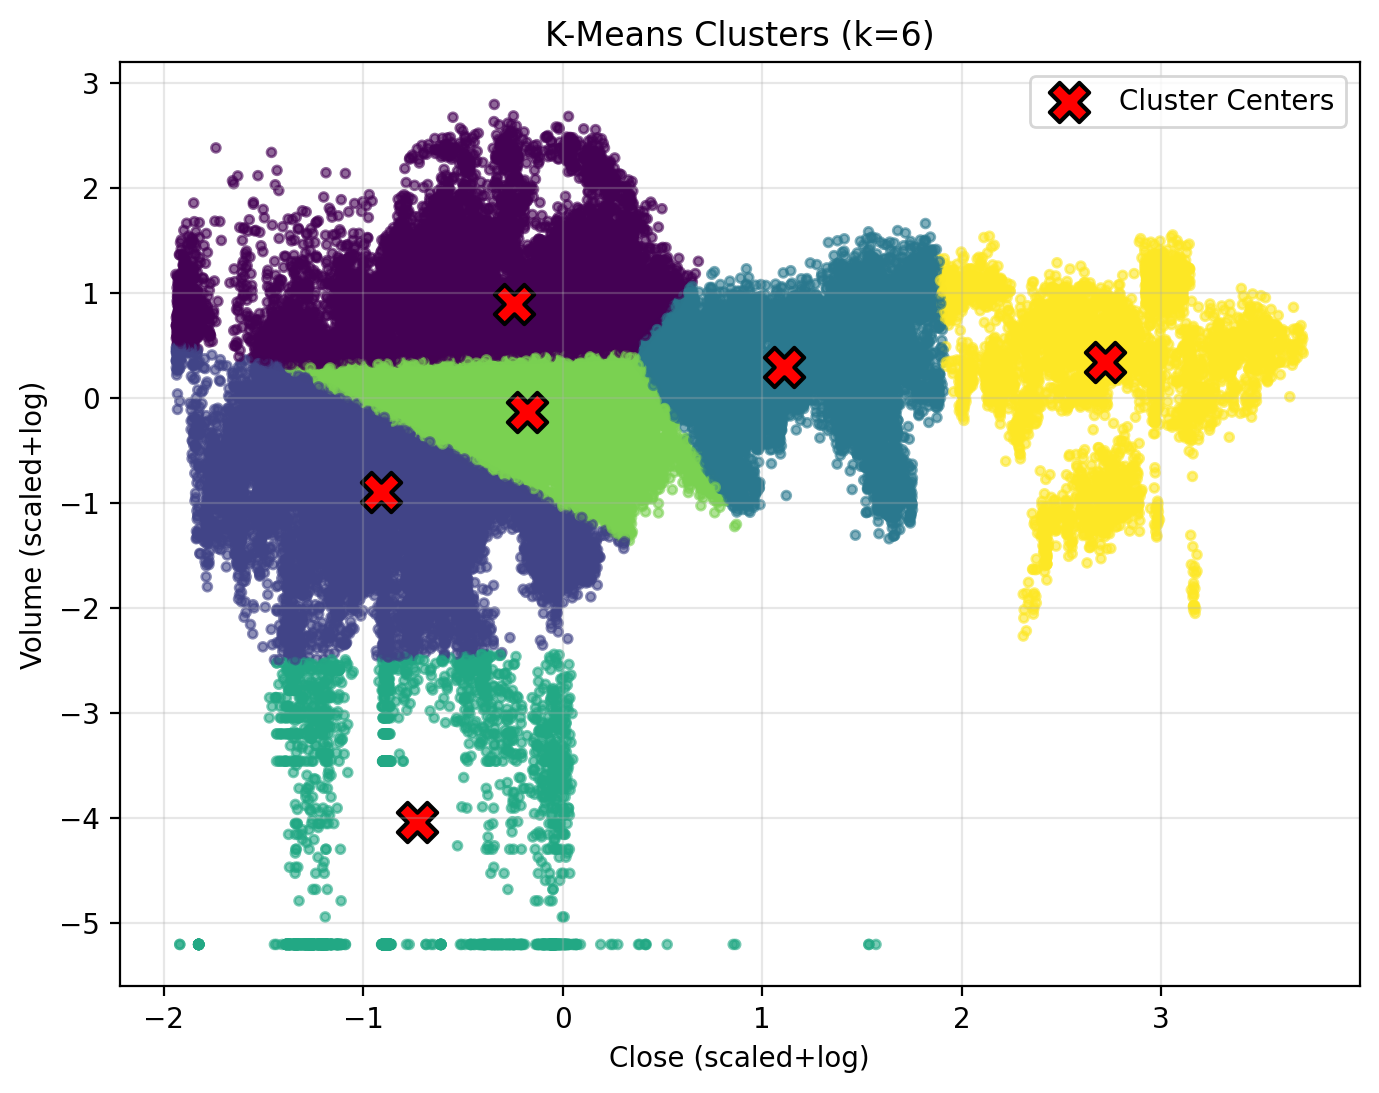

In [ ]:
kmeans3 = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
plot_clusters(X_scaled, kmeans3.labels_, kmeans3.cluster_centers_, 3)
kmeans6 = KMeans(n_clusters=6, random_state=42).fit(X_scaled)
plot_clusters(X_scaled, kmeans6.labels_, kmeans6.cluster_centers_, 6)

# **Scatter plot Results -  applying K-Means clustering with **3 groups** to our tock data from 2023 to 2025**
---

The Colors represent different types of market behavior:

**• Purple cluster in the top left - Expensive hype-driven days**
These are mid-priced stocks with high trading volume, which usually means the market is excited and actively buying.

**• Teal cluster in the bottom left - Quiet low-interest days**
These are low-priced stocks with very low volume, showing quiet market days where traders are not very interested.

**• Yellow cluster on the right side - Active trading in mid-priced stocks**
These points represent very high-priced stocks with strong activity, which reflects the AI-driven surge in semiconductor companies.



# **Scatter plot Results of applying K-Means clustering with  **6groups** to our stock data from 2023 to 2025**
---

The Colors represent different types of market behavior:

**• Purple cluster in the top left - Expensive hype-driven days**
These are mid-priced stocks with high trading volume, which usually means the market is excited and actively buying.

**• Blue-Green (Right Center) - Strong confidence in AI leaders**
 High Price High Volume

**• Yellow (Right) - AI Peak Surge**
Very High Price High Volume Major price spikes during AI boom

**•  Dark Blue (Left-Low Center)  - Calm Normal Days**
Low-Mid Price Low Volume Small movements

**• Teal (Bottom Left) - Low-Interest Days**
Low Price Very Low Volume



# **Decision Tree**



In [ ]:
data.head(10)

,Unnamed: 0,company_name,stock_name,date,open,high,low,close,volume
0,0,NVIDIA,NVDA,2012-01-03,0.327805,0.330097,0.321157,0.321845,468044000
1,1,NVIDIA,NVDA,2012-01-04,0.322074,0.326888,0.319094,0.325513,347372000
2,2,NVIDIA,NVDA,2012-01-05,0.323908,0.338808,0.322533,0.337204,563548000
3,3,NVIDIA,NVDA,2012-01-06,0.336974,0.337204,0.329410,0.333307,533252000
4,4,NVIDIA,NVDA,2012-01-09,0.333536,0.339725,0.331014,0.333307,508244000
5,5,NVIDIA,NVDA,2012-01-10,0.338350,0.338579,0.329639,0.331931,546328000
6,6,NVIDIA,NVDA,2012-01-11,0.328951,0.331931,0.323908,0.325283,484272000
7,7,NVIDIA,NVDA,2012-01-12,0.325971,0.326200,0.316114,0.323220,652364000
8,8,NVIDIA,NVDA,2012-01-13,0.320928,0.321616,0.313134,0.314739,504300000
9,9,NVIDIA,NVDA,2012-01-17,0.319553,0.319553,0.309466,0.309925,627176000


In [ ]:
credo_data = data[(data['company_name'] == 'CREDO') | (data['stock_name'] == 'CRDO')]
display(credo_data.head())

,Unnamed: 0,company_name,stock_name,date,open,high,low,close,volume
111634,111634,Credo Technology,CRDO,2022-01-27,12.10,12.500,10.80,11.65,5371700
111635,111635,Credo Technology,CRDO,2022-01-28,11.64,12.325,11.05,11.19,1317000
111636,111636,Credo Technology,CRDO,2022-01-31,11.44,12.490,11.20,12.12,838400
111637,111637,Credo Technology,CRDO,2022-02-01,12.12,13.700,11.82,12.80,833000
111638,111638,Credo Technology,CRDO,2022-02-02,13.09,13.415,12.80,13.40,2621600


<Axes: xlabel='date'>

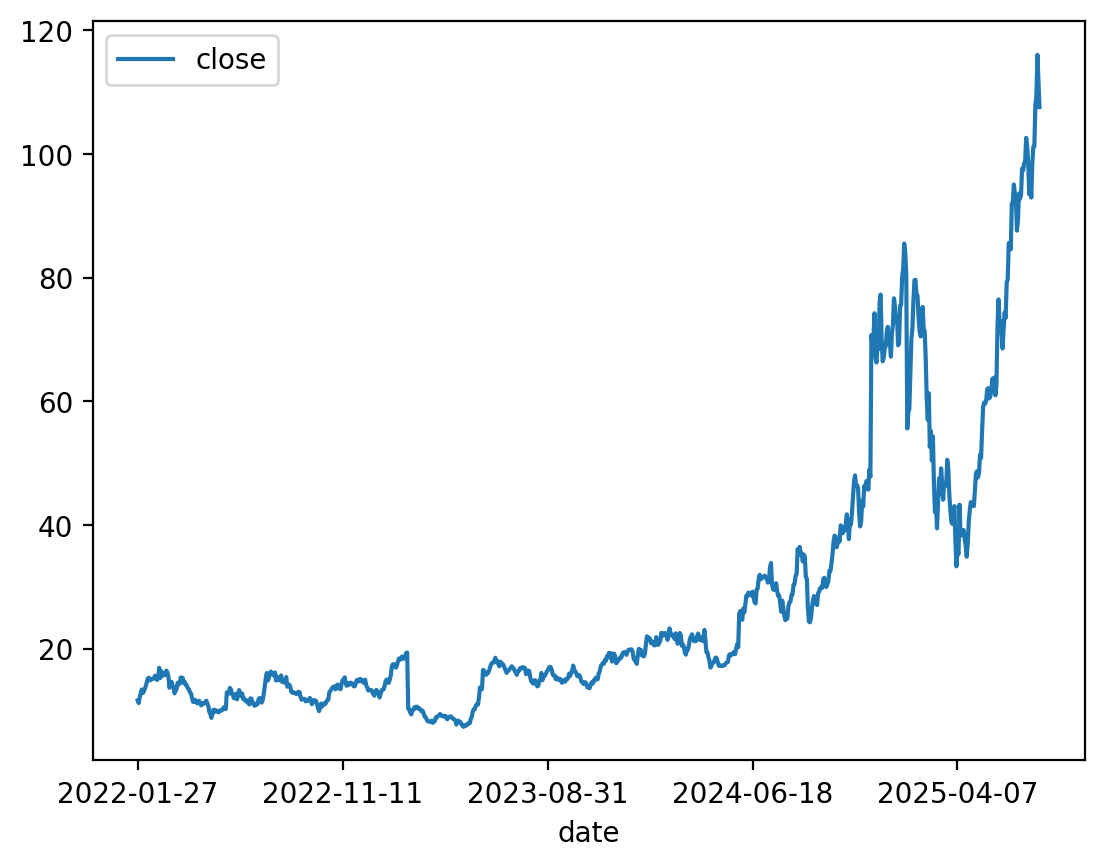

In [ ]:
credo_data.set_index('date', inplace=True)
credo_data.plot.line(y="close")

In [ ]:
credo_data["tomorrow"] = credo_data["close"].shift(-1)
credo_data["Target"] = (credo_data["tomorrow"] > credo_data["close"]).astype(int)
credo_data = credo_data.loc["2012-01-01":].copy()

In [ ]:
credo_data.head(10)

,Unnamed: 0,company_name,stock_name,open,high,low,close,volume,tomorrow,Target
date,,,,,,,,,,
2022-01-27,111634,Credo Technology,CRDO,12.10,12.500,10.80,11.65,5371700,11.19,0
2022-01-28,111635,Credo Technology,CRDO,11.64,12.325,11.05,11.19,1317000,12.12,1
2022-01-31,111636,Credo Technology,CRDO,11.44,12.490,11.20,12.12,838400,12.80,1
2022-02-01,111637,Credo Technology,CRDO,12.12,13.700,11.82,12.80,833000,13.40,1
2022-02-02,111638,Credo Technology,CRDO,13.09,13.415,12.80,13.40,2621600,12.82,0
2022-02-03,111639,Credo Technology,CRDO,13.22,13.290,12.40,12.82,710800,13.07,1
2022-02-04,111640,Credo Technology,CRDO,12.87,13.750,12.87,13.07,345800,13.52,1
2022-02-07,111641,Credo Technology,CRDO,13.39,13.750,13.13,13.52,504600,13.94,1
2022-02-08,111642,Credo Technology,CRDO,13.57,14.120,13.52,13.94,463200,14.64,1


In [ ]:
# 1. Create tomorrow column
credo_data["tomorrow"] = credo_data["close"].shift(-1)

# 2. Create binary Target: 1 if tomorrow's close is higher
credo_data["Target"] = (credo_data["tomorrow"] > credo_data["close"]).astype(int)

# 3. Use data starting from 2012
credo_data = credo_data.loc["2012-01-01":].copy()
credo_data.head()

,Unnamed: 0,company_name,stock_name,open,high,low,close,volume,tomorrow,Target
date,,,,,,,,,,
2022-01-27,111634,Credo Technology,CRDO,12.10,12.500,10.80,11.65,5371700,11.19,0
2022-01-28,111635,Credo Technology,CRDO,11.64,12.325,11.05,11.19,1317000,12.12,1
2022-01-31,111636,Credo Technology,CRDO,11.44,12.490,11.20,12.12,838400,12.80,1
2022-02-01,111637,Credo Technology,CRDO,12.12,13.700,11.82,12.80,833000,13.40,1
2022-02-02,111638,Credo Technology,CRDO,13.09,13.415,12.80,13.40,2621600,12.82,0


In [ ]:
# 4. Import Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score

# 5. Split train/test (same as you did)
train = credo_data.iloc[:-100]
test = credo_data.iloc[-100:]

# 6. Select predictors
predictors = ["close", "volume", "open", "high", "low"]

# 7. Train the Decision Tree using your known good hyperparameters
model = DecisionTreeClassifier(
    max_depth=4,           # similar to RF behavior based on your data
    min_samples_leaf=20,   # similar stability to RF's min_samples_split=100
    random_state=1
)

model.fit(train[predictors], train["Target"])#using predictors columns to predict the target



DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=1)

In [ ]:

# 8. Predict
preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
preds


,0
date,
2025-03-11,1
2025-03-12,1
2025-03-13,0
2025-03-14,0
2025-03-17,1
...,...
2025-07-28,0
2025-07-29,0
2025-07-30,0


In [ ]:
preds = pd.Series(preds, index=test.index)#turning numpy array into Pandas series

In [ ]:
precision_score(test["Target"], preds)

0.48148148148148145

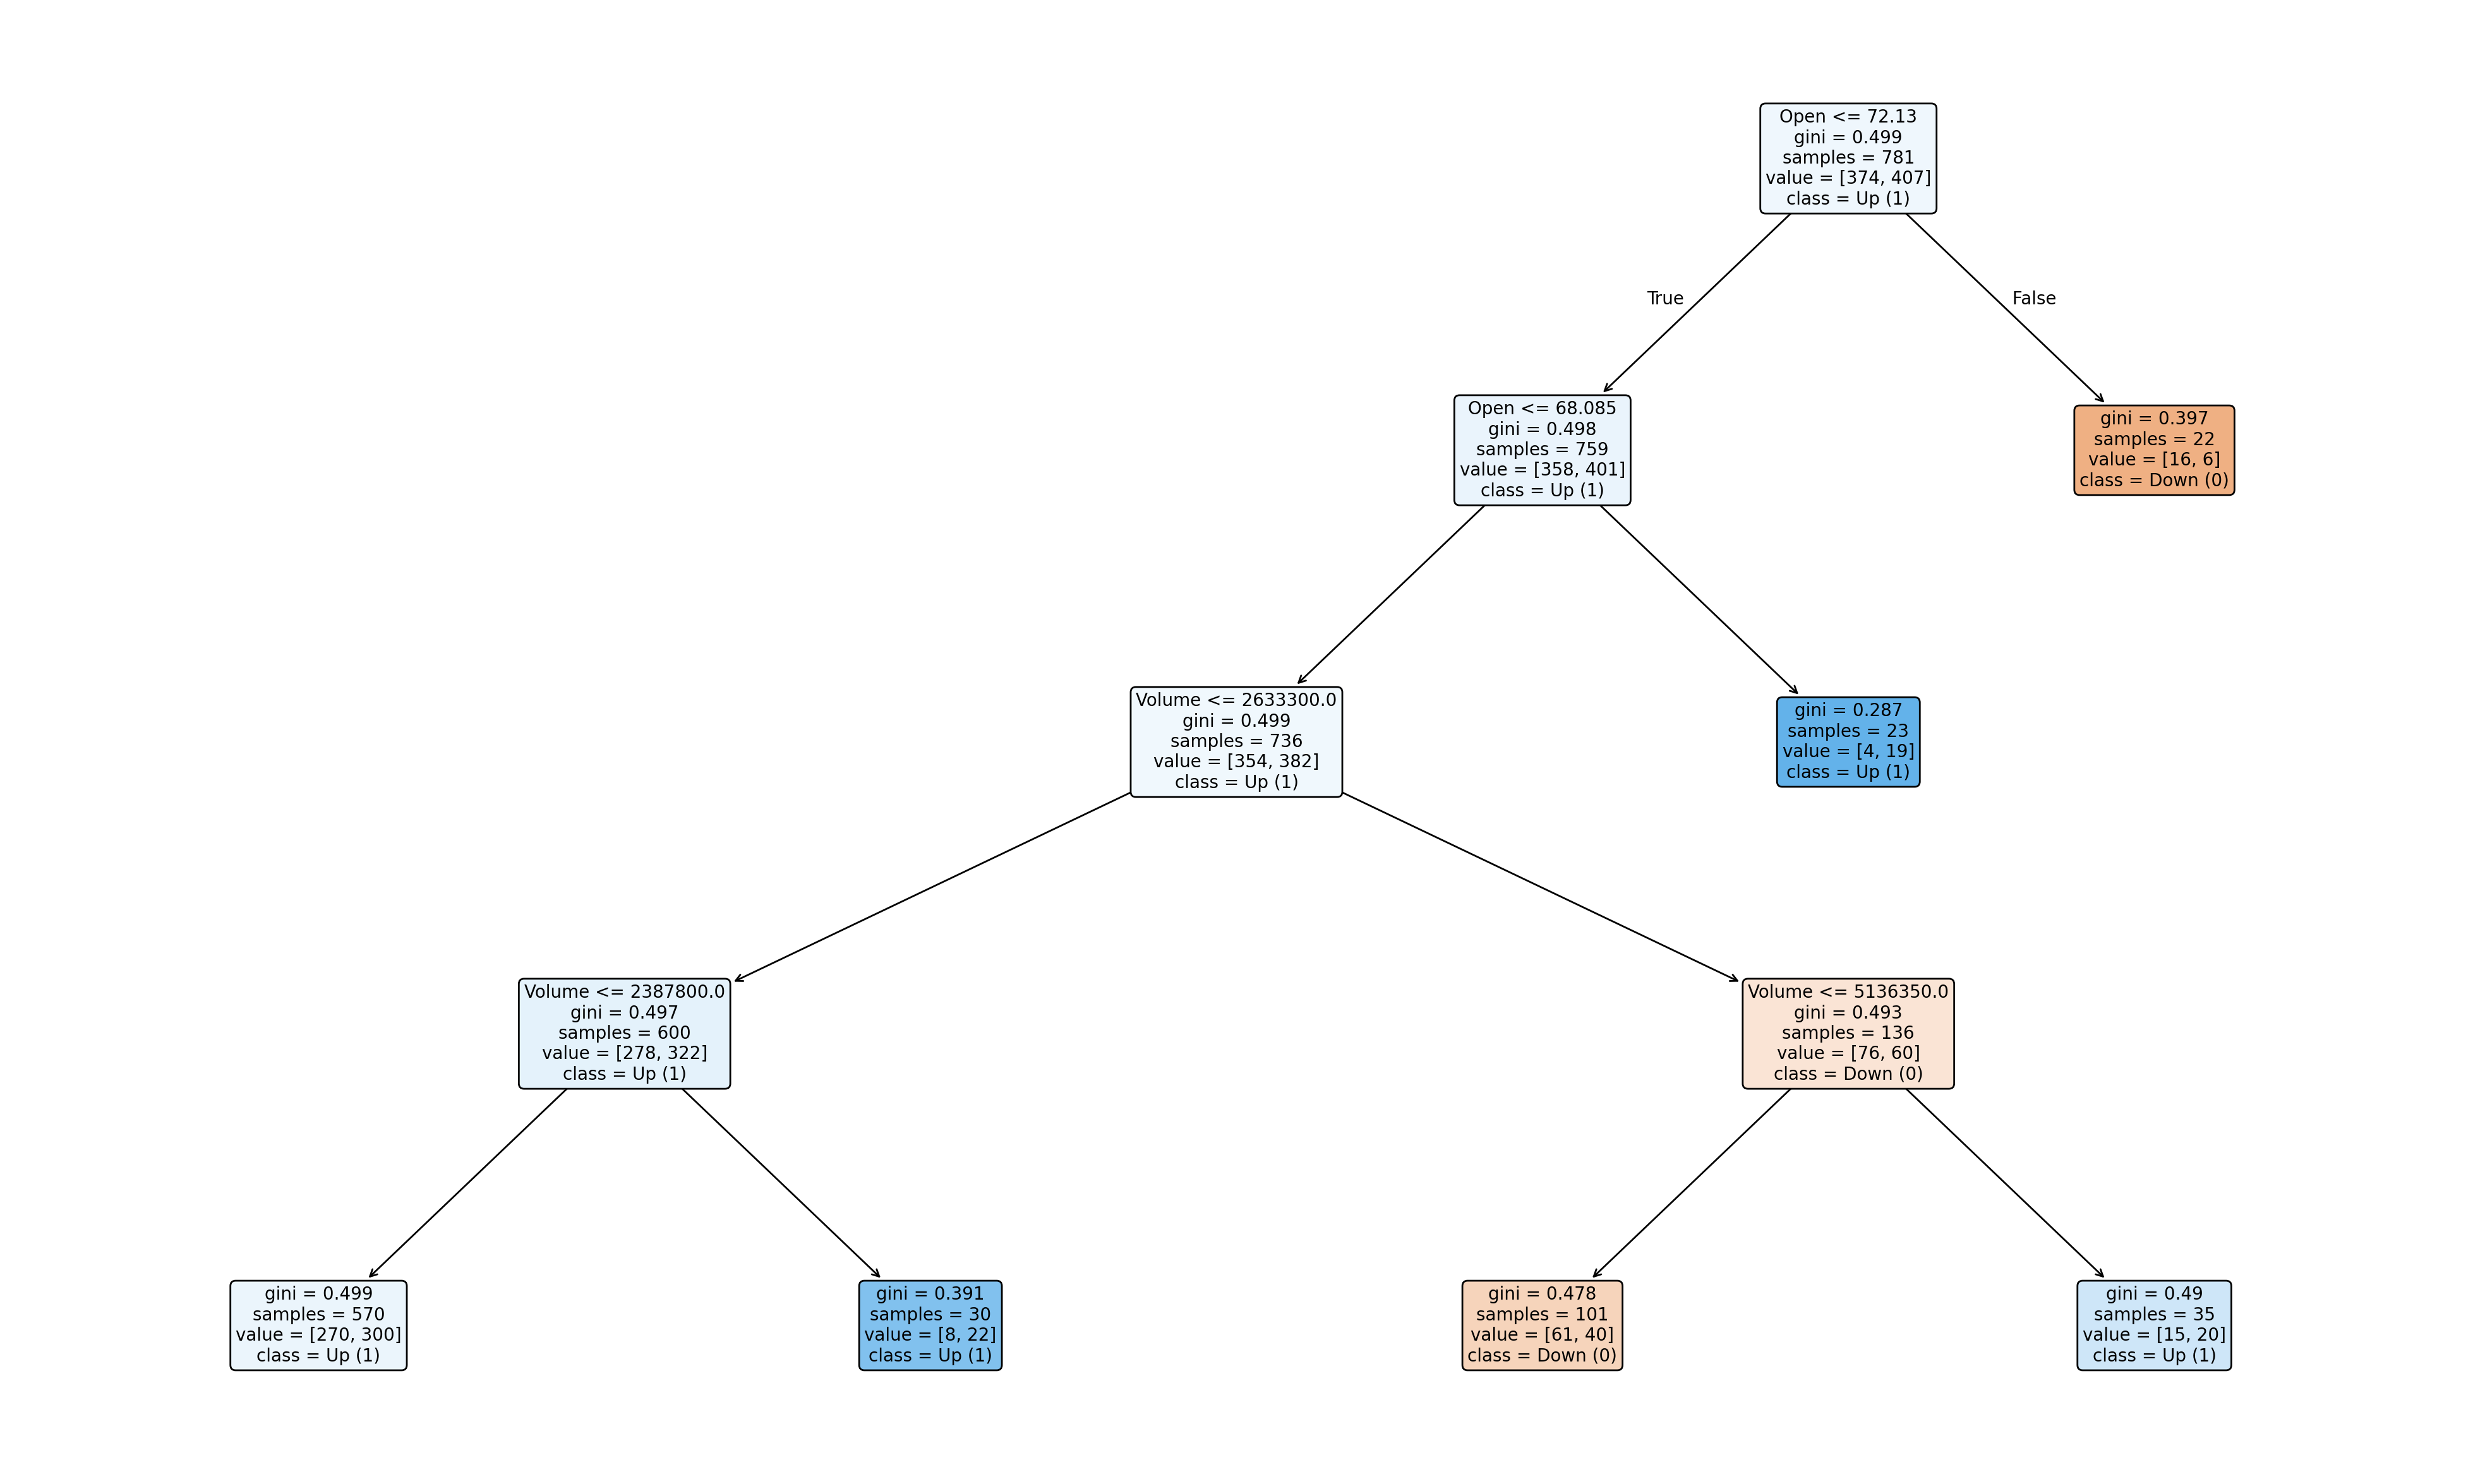

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Feature names
X_names = ["Close", "Volume", "Open", "High", "Low"]

# Class names for the target
y_names = ["Down (0)", "Up (1)"]

# Create a large figure so the tree is readable
fig = plt.figure(figsize=(25, 15))

_ = plot_tree(
    model,               # your trained DecisionTreeClassifier
    feature_names=X_names,
    class_names=y_names,
    filled=True,
    rounded=True,
    fontsize=10
)

# Save the figure
fig.savefig("decision_tree_credo.jpg", dpi=300)

# **Error Evaluation**

0.48 - not a good precision score, less than without the model, but we can improve it by training rolling averages.
first, analyze with the plot

orange line - what the model predicted, so we see that we predicted price go down, when it actually went up (blue line)



<Axes: title={'center': 'Decision Tree Predictions vs Actual'}, xlabel='date'>

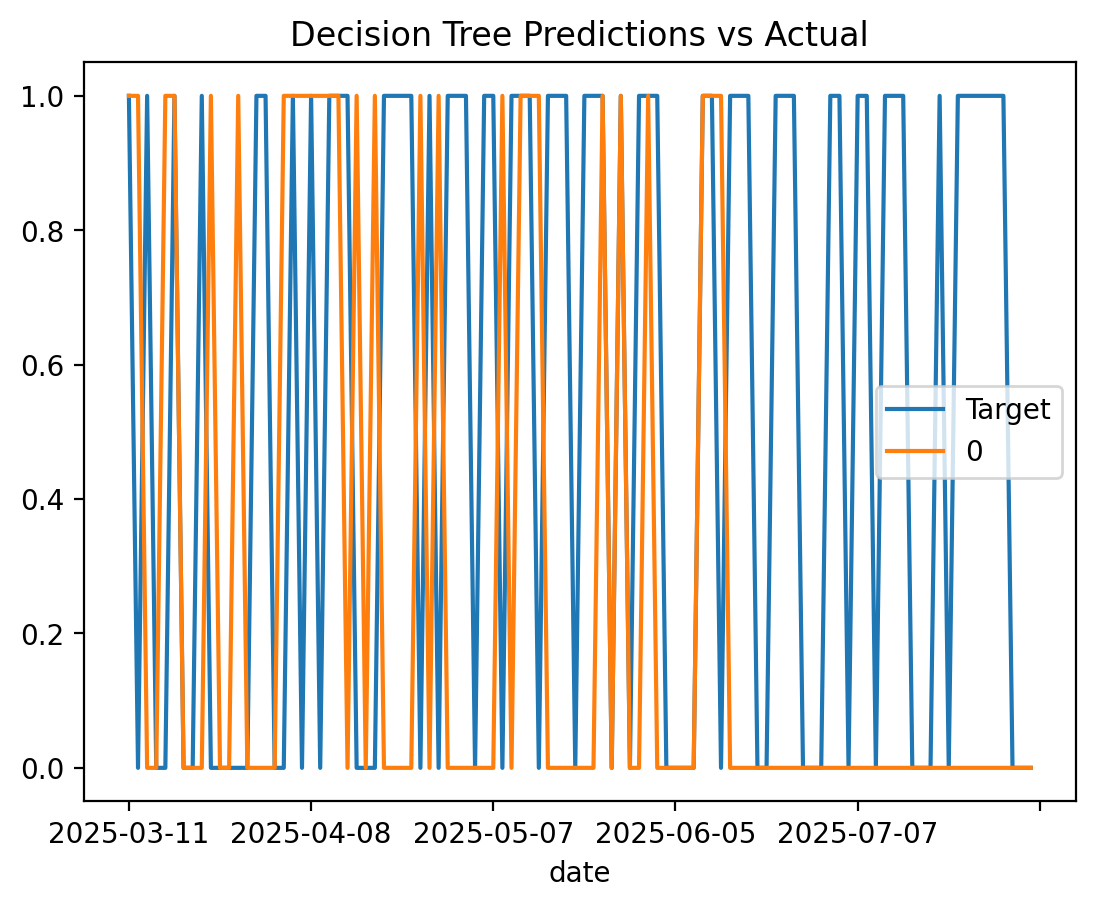

In [ ]:
# Optional: visualize predictions
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot(title="Decision Tree Predictions vs Actual")

# **Improving the model- Adding predictors**

* We will use **rolling averages on the close column** to improve the results

* We will add features, that are **Ratios**, to see **how much price today is greater/lesser, than it was last week, last month, last year**

* Also, add **Trend feature** - sum of the target for each day over the last given days

* It should give us improvement from the baseline model as we only compared today and tommorrow value before.

  Now we will **give algorithm more information about those periods**:
  
   if the market went up - sector, or a specific asset experiences a decline in value

   if the market went down - positive movement in market prices, often within a larger trend.








In [ ]:
horizons = [2,5,60,250]
#calculate the mean close price in the last:
# two days
# 5 days - trading week
# 60 days
# 250 days -trading year
new_predictors = []

for horizon in horizons:
    # calculate rolling mean for the 'close' column
    rolling_averages_close = credo_data["close"].rolling(horizon).mean()


    # calculate rolling mean for the 'close' column
    ratio_column = f"Close_Ratio_{horizon}"
    credo_data[ratio_column] = credo_data["close"] / rolling_averages_close

    # calculate sum of the target for each day over the last given days
    trend_column = f"Trend_{horizon}"
    # look at the past days (one of the last values) and calculate the average number of Target values of those days
    credo_data[trend_column] = credo_data["Target"].shift(1).rolling(horizon).sum()

    new_predictors+= [ratio_column, trend_column]

In [ ]:
credo_data.head()

,Unnamed: 0,company_name,stock_name,open,high,low,close,volume,tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250
date,,,,,,,,,,,,,,,,,,
2023-01-26,111884,Credo Technology,CRDO,17.650000,17.650000,16.709999,17.490000,1645400,17.309999,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-27,111885,Credo Technology,CRDO,17.500000,17.510000,17.030001,17.309999,1744400,16.920000,0,0.994828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-30,111886,Credo Technology,CRDO,16.930000,17.160000,16.309999,16.920000,2254600,17.330000,1,0.988607,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-31,111887,Credo Technology,CRDO,16.879999,17.540001,16.809999,17.330000,1986400,17.940001,1,1.011971,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-01,111888,Credo Technology,CRDO,17.320000,18.170000,16.690001,17.940001,3442600,18.389999,1,1.017295,2.0,1.031153,NaN,NaN,NaN,NaN,NaN


In [ ]:
credo_data.tail()

,Unnamed: 0,company_name,stock_name,open,high,low,close,volume,tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250
date,,,,,,,,,,,,,,,,,,
2025-07-25,112509,Credo Technology,CRDO,100.150002,102.919998,99.800003,101.220001,2304800,107.949997,1,1.000247,2.0,1.033976,4.0,1.330188,37.0,1.859129,140.0
2025-07-28,112510,Credo Technology,CRDO,104.629997,108.040001,103.419998,107.949997,4507600,109.379997,1,1.032175,2.0,1.075885,4.0,1.398748,38.0,1.971246,140.0
2025-07-29,112511,Credo Technology,CRDO,110.000000,112.669998,108.519997,109.379997,4566100,116.010002,1,1.006580,2.0,1.055527,5.0,1.398003,38.0,1.985467,141.0
2025-07-30,112512,Credo Technology,CRDO,111.980003,116.598999,111.250000,116.010002,4712800,111.550003,0,1.029416,2.0,1.082728,5.0,1.461648,38.0,2.092136,142.0
2025-07-31,112513,Credo Technology,CRDO,117.974998,118.949997,110.879997,111.550003,5513400,107.559998,0,0.980401,1.0,1.021314,4.0,1.387145,37.0,1.999616,141.0


NaN here indicates there that there is not enough days prior to the current day, so rolling average
credo_data.dropna()

In [ ]:
credo_data = credo_data.dropna(subset=credo_data.columns[credo_data.columns != "Tomorrow"])

In [ ]:
model = DecisionTreeClassifier(
    max_depth=4,           #
    min_samples_leaf=20,   # Every leaf node (final decision endpoint) must contain at least 20 samples
    random_state=1
)

# **Improving the model - Custom Threshhold**

* before default threshhold was used, we increase it to 0.7,
* meaning: if there is a greater than a 50 percent chance than a price will go up , the model return that the price will go up

* meaning the model will need to be more confident to predict up, that will **reduce the number of days, but increase the chance that the price will go up**


**Recomendation**:        
* this can be change for different cases, here, 0.7 value provided max precision compared to 0.4, 0.5, 0.6 values

* min_sample_leaf from above value also can be changed depending on the data available, with more rows used, split value also would be increased



In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.7] = 1
    preds[preds <.7] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

# Running the model again

In [ ]:
def backtest(data, model, predictors, start=750, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [ ]:
predictions = backtest(credo_data, model, new_predictors, start=400, step=100)

### **Final Evaluation**

In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5789473684210527

In [ ]:
print(round(precision_score(predictions["Target"], predictions["Predictions"]), 2))

0.58




*   **Meaning** : On days model says to buy, the price actually goes up 58 percent.


*    **The model have predictetive value**, even though score 58 may not seem right, it is actually pretty good given that we had just time-series data and only historical prices.

*   **Numerically**, it would have give money if used from 2012, but ,of course, it is not recomended for trading.


*    Lastly, it **shows improvement from the baseline** - first mode's score, indicating possibility for futher improvements

# **Final Decision Tree Plot**

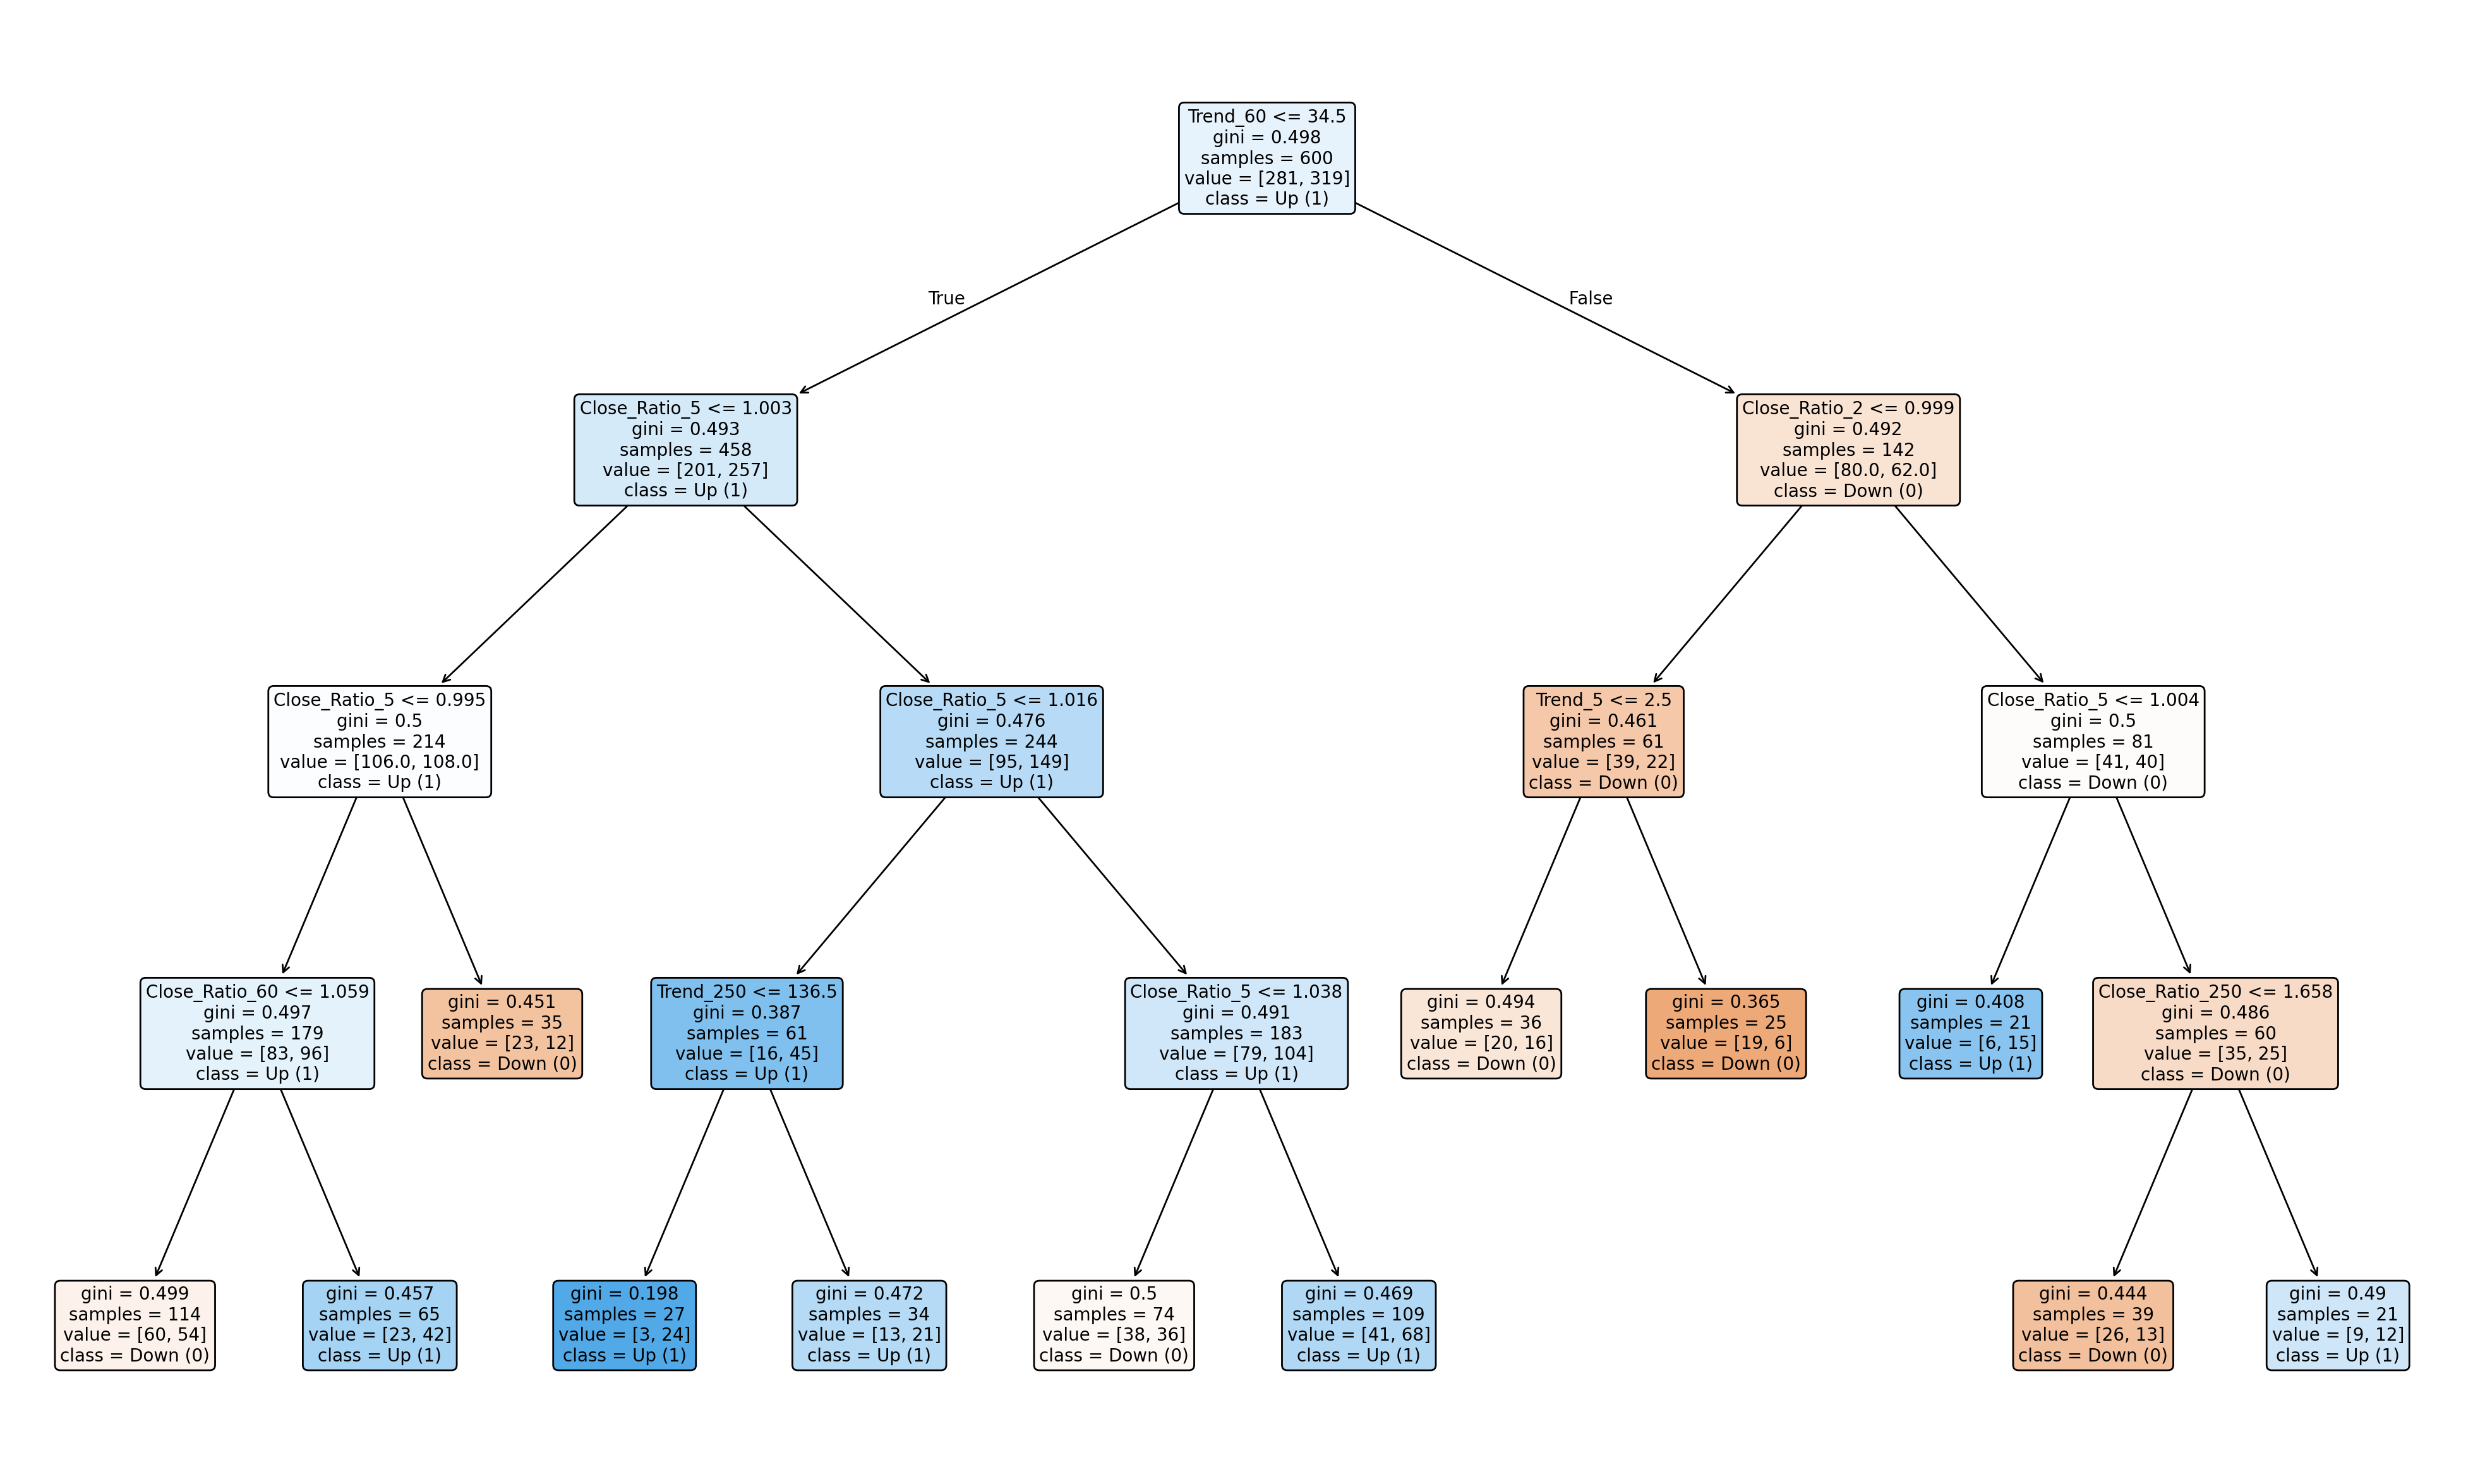

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Feature namesClose_Ratio_2	Trend_2	Close_Ratio_5	Trend_5	Close_Ratio_60	Trend_60
X_names = ["Close_Ratio_2", "Trend_2", "Close_Ratio_5", "Trend_5", "Close_Ratio_60", "Trend_60", "Close_Ratio_250", "Trend_250" ]

# Class names for the target
y_names = ["Down (0)", "Up (1)"]

# Create a large figure so the tree is readable
fig = plt.figure(figsize=(25, 15))

_ = plot_tree(
    model,               # your trained DecisionTreeClassifier
    feature_names=X_names,
    class_names=y_names,
    filled=True,
    rounded=True,
    fontsize=10
)

# Save the figure
fig.savefig("decision_tree_credo.jpg", dpi=300)

### **Final Decision Tree Plot**

This final Decision Tree plot provides valuable insights into how  model makes predictions:


*   **Decision Logic**
    
     
      As you can see from the plot we replaced values of high, low, open, in the predictions. Those are absolute values that carry much less meaning compared to ratios, of how price changed.
      
      Each node in the tree represents a decision point based on one of added features. Node might split based on whether `Close_Ratio_5` (current price vs. 5-day average) is above or below a certain threshold. This helps the model identify patterns like:

     If the price has been going up for the last 5 days (`Close_Ratio_5` > 0.7 ) and the long-term trend (`Trend_250`) is also positive, then predict an 'Up' day.

* **Leaves and Predictions**
    
     The leaf nodes (the very bottom of the tree) show the final prediction (Up or Down) along with the `samples` (number of data points that reached that leaf) and `value` (distribution of 'Up' vs 'Down' days in that leaf).

Overall, the new features provided the model more contextual understanding of price dynamics beyond simple today/tommorow values comparisons used before. We incorporate short, medium, and long-term indicators, that significanlty improved the model.

# **References:**
Dataset [27] F. Keçe. "Semiconductor Stocks and the AI Surge." Kaggle.com. Accessed: Oct 20, 2025
Online. Available: https://www.kaggle.com/datasets/farukece/semiconductor-stocks-and-the-ai-surge

Background Research: M. Intrator (CoreWeave CEO). "CoreWeave CEO pushes back against circular investment concerns." CNBC.com, Oct. 8, 2025. [Online]. Available: https://www.cnbc.com/2025/10/08/coreweave-ceo-pushes-back-against-circular-investment-concerns-.html

Report [28] Global Market Intelligence. "AI Infrastructure: Midyear 2025 Update and Future Technology Considerations." spglobal.com. October 2025. [Online]. Available: https://www.spglobal.com/market-intelligence/en/news-insights/research/2025/10/ai-infrastructure-midyear-2025-update-and-future-technology-considerations

Decision tree: V. Paruchuri. "S&P 500 Stock Market Forecasting" GitHub.com. Accessed: Nov 20, 2025,Online Available: https://github.com/dataquestio/projectwalkthroughs/blob/master/sp_500/market_prediction.ipynb

Time-series Analysis studies (ch 16), K-means clustering (ch 15) , idea on data partition (16.5):
Shmueli, Galit, et al. Data Mining for Business Analytics : Concepts, Techniques and Applications in Python, JohnWiley & Sons, Incorporated, 2019. ProQuest Ebook Central, http://ebookcentral.proquest.com/lib/senecac/detail.action?docID=5945647
